# Building a network

The purpose of this notebook is to create a network to control an effector, and to train it to perform a task through the optimization process. We will also briefly cover how to save and re-load a network.

For how to build an effector and environment from scratch, feel free to look up the `1-build-effector.ipynb` and `3-environments.ipynb` notebooks.

Let's start by importing what we need.


In [1]:
import os
import sys
import json
import numpy as np
import torch as th
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Auto-install motornet if this kernel doesn't already have it.
#   Colab -> no local checkout, so pull from GitHub.
#   Local -> install the sibling ../MotorNet clone editable, so source edits stay live.
try:
    import motornet as mn
except ImportError:
    if 'google.colab' in sys.modules:
        !pip install -q gymnasium "git+https://github.com/motornet-org/MotorNet"
    else:
        # --python pins uv to *this* kernel; --no-deps keeps the local CUDA torch build
        !uv pip install -q --python {sys.executable} gymnasium
        !uv pip install -q --python {sys.executable} --no-deps -e ../MotorNet
        sys.path.append(os.path.abspath("../MotorNet"))  # a fresh .pth isn't read mid-kernel
    import motornet as mn

print('All packages imported.')
print('pytorch version: ' + th.__version__)
print('numpy version: ' + np.__version__)
print('motornet version: ' + mn.__version__)


All packages imported.
pytorch version: 2.13.0+cu130
numpy version: 2.5.1
motornet version: 0.3.0



# I. Introduction

Since the purpose of this notebook is not to show how to build an effector or an environment, we will use a pre-built effector and environment that comes with the `motornet` toolbox. This is a 4-muscles point mass plant, with `ReluMuscle` actuators, and a simple random-to-random position reaching task.

Generally speaking, the objects we create follow the hierarchical structure illustrated below.




<img src="img/hierarchy.png" alt="drawing" width="500"/>


# II. Building the model

## II. 1. `Effector` and `Environment` instances.
All the elements below take from previous tutorials, so we are just repeating them here.

Note that we specify the maximum duration of an episode to be 1 sec. We set this up explicitly here, but this is actually the default if no value is provided.

In [2]:

effector = mn.effector.ReluPointMass24()
env = mn.environment.RandomTargetReach(effector=effector, max_ep_duration=1.)


## II. 2. Building the network

This step simply reduces to building a `torch.nn.Module` subclass. If you are not sure on how to achieve that, there are many tutorials available online for learning PyTorch basics.

A good and simple model for this kind of task is to have one recurrent layer receiving observation inputs, so the input dimension is the size of the observation vector. Here we specify the recurrent layer to be one layer of 32 Gated Recurrent Units (GRUs). The output layer is a simple fully connected linear layer, with a sigmoid non-linearity.

Note that we initialize the fully connected layer's bias to be `-5`, to ensure we start the training with low output forces and therefore a more stable situation. Also note that the action that should be input into the environment should be bounded from 0 to 1, which the sigmoid guarantees.

In [3]:


class Policy(th.nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, device):
        super().__init__()
        self.device = device
        self.hidden_dim = hidden_dim
        self.n_layers = 1
        
        self.gru = th.nn.GRU(input_dim, hidden_dim, 1, batch_first=True)
        self.fc = th.nn.Linear(hidden_dim, output_dim)
        self.sigmoid = th.nn.Sigmoid()

        # the default initialization in torch isn't ideal
        for name, param in self.named_parameters():
            if name == "gru.weight_ih_l0":
                th.nn.init.xavier_uniform_(param)
            elif name == "gru.weight_hh_l0":
                th.nn.init.orthogonal_(param)
            elif name == "gru.bias_ih_l0":
                th.nn.init.zeros_(param)
            elif name == "gru.bias_hh_l0":
                th.nn.init.zeros_(param)
            elif name == "fc.weight":
                th.nn.init.xavier_uniform_(param)
            elif name == "fc.bias":
                th.nn.init.constant_(param, -5.)
            else:
                raise ValueError
        
        self.to(device)

    def forward(self, x, h0):
        y, h = self.gru(x[:, None, :], h0)
        u = self.sigmoid(self.fc(y)).squeeze(dim=1)
        return u, h
    
    def init_hidden(self, batch_size):
        weight = next(self.parameters()).data
        hidden = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().to(self.device)
        return hidden
    
device = th.device("cpu")

policy = Policy(env.observation_space.shape[0], 32, env.n_muscles, device=device)
optimizer = th.optim.Adam(policy.parameters(), lr=10**-3)



We can then train the `Policy` network like we would any PyTorch model. The output of the `Policy` is then passed as input to the `Environment` object using the `Environment.step()` method. The `obs` and `info` ouputs are then collected and used for the loss computation and the backward pass.

Importantly, adding some clipping greatly improves the training process for motor tasks in general.

In [4]:

batch_size = 32
n_batch = 6000
losses = []
interval = 250

def l1(x, y):
  """L1 loss"""
  return th.mean(th.sum(th.abs(x - y), dim=-1))

for batch in range(n_batch):
  # initialize batch
  h = policy.init_hidden(batch_size=batch_size)
  obs, info = env.reset(options={"batch_size": batch_size})
  terminated = False

  # initial positions and targets
  xy = [info["states"]["fingertip"][:, None, :]]
  tg = [info["goal"][:, None, :]]

  # simulate whole episode
  while not terminated:  # will run until `max_ep_duration` is reached
    action, h = policy(obs, h)
    obs, reward, terminated, truncated, info = env.step(action=action)

    xy.append(info["states"]["fingertip"][:, None, :])  # trajectories
    tg.append(info["goal"][:, None, :])  # targets

  # concatenate into a (batch_size, n_timesteps, xy) tensor
  xy = th.cat(xy, axis=1)
  tg = th.cat(tg, axis=1)
  loss = l1(xy, tg)  # L1 loss on position
  
  # backward pass & update weights
  optimizer.zero_grad() 
  loss.backward()
  th.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.)  # important!
  optimizer.step()
  losses.append(loss.item())

  if (batch % interval == 0) and (batch != 0):
    print("Batch {}/{} Done, mean policy loss: {}".format(batch, n_batch, sum(losses[-interval:])/interval))



Batch 250/6000 Done, mean policy loss: 0.6411923236846924


Batch 500/6000 Done, mean policy loss: 0.25547943633794784


Batch 750/6000 Done, mean policy loss: 0.20236769634485244


Batch 1000/6000 Done, mean policy loss: 0.17482725214958192


Batch 1250/6000 Done, mean policy loss: 0.15982000648975372


...

Batch 4750/6000 Done, mean policy loss: 0.11137220445275307


Batch 5000/6000 Done, mean policy loss: 0.11113163799047471


Batch 5250/6000 Done, mean policy loss: 0.11117898127436637


Batch 5500/6000 Done, mean policy loss: 0.10764888229966163


Batch 5750/6000 Done, mean policy loss: 0.1100813966691494


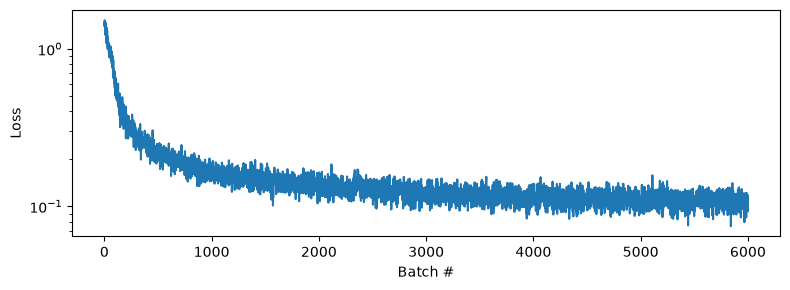

In [5]:
def plot_training_log(log):
  fig, axs = plt.subplots(1, 1)
  fig.set_tight_layout(True)
  fig.set_size_inches((8, 3))

  axs.semilogy(log)

  axs.set_ylabel("Loss")
  axs.set_xlabel("Batch #")
  plt.show()

plot_training_log(losses)

# III. Evaluating performance

A forward pass on the model (with `deterministic=True`) will yield the evaluation behaviour.

We can plot the resulting states to quickly visualize what the network is doing.


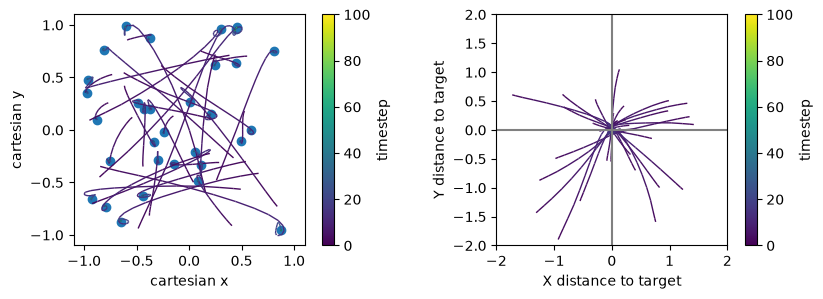

In [6]:
plotor = mn.plotor.plot_pos_over_time

def plot_simulations(xy, target_xy):
  target_x = target_xy[:, -1, 0]
  target_y = target_xy[:, -1, 1]

  plt.figure(figsize=(10,3))

  plt.subplot(1,2,1)
  plt.ylim([-1.1, 1.1])
  plt.xlim([-1.1, 1.1])
  plotor(axis=plt.gca(), cart_results=xy)
  plt.scatter(target_x, target_y)

  plt.subplot(1,2,2)
  plt.ylim([-2, 2])
  plt.xlim([-2, 2])
  plotor(axis=plt.gca(), cart_results=xy - target_xy)
  plt.axhline(0, c="grey")
  plt.axvline(0, c="grey")
  plt.xlabel("X distance to target")
  plt.ylabel("Y distance to target")
  plt.show()


plot_simulations(xy=th.detach(xy), target_xy=th.detach(tg))


# IV. Saving the model

Next, we can save the network like we would any PyTorch model. We will also save the training history as a `.json` file, and the environment's configuration information for later reference.


In [7]:

weight_file = os.path.join("save", "weights")
log_file = os.path.join("save", "log.json")
cfg_file = os.path.join("save", "cfg.json")


# save model weights
th.save(policy.state_dict(), weight_file)


# save training history (log)
with open(log_file, 'w') as file:
  json.dump(losses, file)


# save environment configuration dictionary
cfg = env.get_save_config()
with open(cfg_file, 'w') as file:
  json.dump(cfg, file)


print("done.")


done.



# V. Loading the model

## V. 1. The configuration file
This file is what the `Environment.get_save_config()` method produces. It contains a dictionary with all the parameter and configuration values used to create the environment. Let's look into its structure quickly.


In [8]:


with open(cfg_file, 'r') as file:
    cfg = json.load(file)


for k1, v1 in cfg.items():
  if isinstance(v1, dict):
    print(k1 + ":")
    for k2, v2 in v1.items():
      if type(v2) is dict:
        print("\t\t" + k2 + ":")
        for k3, v3 in v2.items():
          print("\t\t\t\t" + k3 + ": ", v3)
      else:
        print("\t\t" + k2 + ": ", v2)
  else:
    print(k1 + ": ", v1)


name:  Env
T_destination:  ~T_destination
action_frame_stacking:  0
action_noise:  [0.0, 0.0, 0.0, 0.0]
call_super_init:  False
delay_range:  [0, 0]
device:  cpu
differentiable:  True
dt:  0.01
dump_patches:  False
elapsed:  1.0000000000000007
max_ep_duration:  1.0
metadata:
		render_modes:  []
n_muscles:  4
np_random_seed:  127722642973371991366534302232391462960
nq_init:  None
obs_noise:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
proprioception_delay:  1
proprioception_noise:  [0.0]
q_init:  None
render_mode:  None
seed:  None
space_dim:  2
spec:  None
training:  True
vision_delay:  1
vision_noise:  [0.0]
effector:
		muscle:
				name:  ReluMuscle
				state names:  ['activation', 'muscle length', 'muscle velocity', 'force']
		skeleton:
				dof:  2
				dt:  0.01
				space_dim:  2
				mass:  1
		dt:  0.01
		n_ministeps:  1
		minidt:  0.01
		half_minidt:  0.005
		muscle_names:  ['UpperRight', 'UpperLeft', 'LowerRight', 'LowerLeft']
		n_muscles:  4
		muscle_wrapping_cfg


## V. 2. Training history

We can use the `.json` file containing the training history to retrieve and plot losses over time.

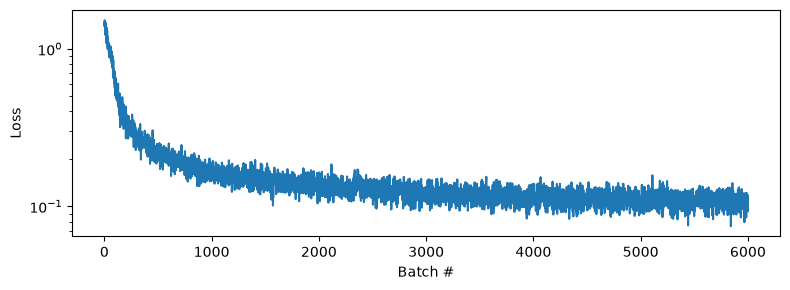

In [9]:
# retrieve and plot training history
with open(log_file, 'r') as file:
    loaded_training_log = json.load(file)

plot_training_log(log=loaded_training_log)




## V. 3. The model itself

Usually, reloading the model would involve re-creating the same model, and applying the trained weights to that model again. To re-create the model, one could re-use the same function as was used to create the original model (that's what we will do here), or one could exploit the configuration file we saved and re-loaded above to recreate a model exhaustively. The latter method might be more tedious to implement but has the benefit of being more exhaustive on the long run.


In [10]:

env2 = mn.environment.RandomTargetReach(effector=mn.effector.ReluPointMass24(), max_ep_duration=1.)
policy2 = Policy(env.observation_space.shape[0], 32, env.n_muscles, device=device)

policy2.load_state_dict(th.load(weight_file))


<All keys matched successfully>


# VI. Evaluating the loaded model

We can then do a forward pass the loaded model like we did on the original model.



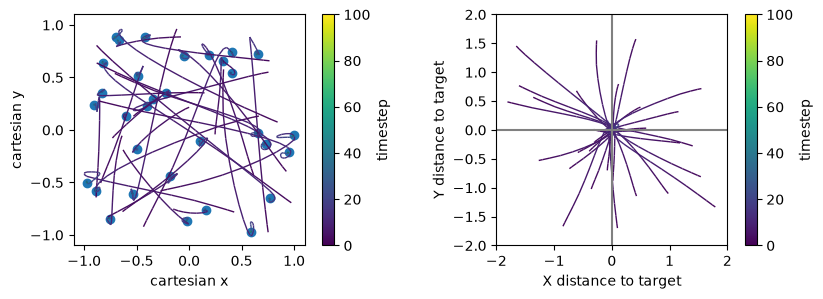

In [11]:
# ==========
# Evaluation
# ==========

# initialize batch
h = policy.init_hidden(batch_size=batch_size)
obs, info = env.reset(options={"batch_size": batch_size})
terminated = False

# initial positions and targets
xy = [info["states"]["fingertip"][:, None, :]]
tg = [info["goal"][:, None, :]]

# simulate whole episode
while not terminated:  # will run until `max_ep_duration` is reached
  action, h = policy(obs, h)
  obs, reward, terminated, truncated, info = env.step(action=action)

  xy.append(info["states"]["fingertip"][:, None, :])  # trajectories
  tg.append(info["goal"][:, None, :])  # targets

# concatenate into a (batch_size, n_timesteps, xy) tensor
xy = th.detach(th.cat(xy, axis=1))
tg = th.detach(th.cat(tg, axis=1))

plot_simulations(xy=xy, target_xy=tg)


# VII. The gym environment at a glance

*(Sections I–VI above are the original MotorNet tutorial and are left untouched. Everything from here down is added.)*

**The environment in three sentences.** A **1 kg point mass** lives in a 2D box, `[-1, 1]²`. Four **muscles** are anchored at the corners of a larger `±2` frame and each pulls the mass toward its own corner — muscles *pull and never push*, so the four of them form an **over-actuated, non-negative** basis: any direction needs a *combination* of muscles, and opposing pairs can **co-contract** to stiffen the limb without moving it. Each episode, `reset()` draws both a random start and a random target in the box, and the network gets **1 second (100 steps × 10 ms)** to close the gap.

| | |
|---|---|
| **Observation** | `Box(-inf, inf, (12,))` = target `xy` (2) + vision of fingertip `xy` (2) + proprioception (8: 4 muscle lengths, 4 muscle velocities) |
| **Action** | `Box(0, 1, (4,))` — one non-negative excitation per muscle; force = `activation × 500 N` |
| **Reward** | **MotorNet ships none** (`step()` returns `None` when `differentiable=True`). We add a bounded one below. |
| **States** | `joint`, `cartesian`, `fingertip`, `muscle`, `geometry` — the full plant state, all differentiable |

Cell `VII.1` sets the environment up (GPU + reward); cell `VII.2` is the single figure that shows all of it.

In [12]:
# ==============================================================================
# VII. 1  The gym environment: on the GPU, with a reward
# ------------------------------------------------------------------------------
# Three things MotorNet does not give us out of the box. All are added by
# SUBCLASSING -- the MotorNet checkout is a git submodule and is never edited.
#
#   1. device   `env.to("cuda")` moves the registered buffers, but Effector /
#               Skeleton / Muscle each cache their own `_device` attribute and
#               `nn.Module._apply` never updates it. The muscle then builds its
#               initial state on the CPU and reset() dies with a device mismatch.
#               `env_to()` sets the cached attribute on all four objects.
#
#   2. noise    `Environment.apply_noise` round-trips through numpy on every call
#               (3x per step) even when the noise vector is all zeros -- which is
#               the default. On GPU that is a host sync + H2D copy per step. We
#               skip no-op noise and sample the rest on-device. Bit-exact.
#
#   3. reward   `Environment.step` returns reward=None when differentiable=True
#               (and hard-coded zeros otherwise): MotorNet has NO task reward.
#               Every reinforcement rule in section VIII (RTRRL, BTSP, R-STDP,
#               3-factor Hebbian) needs a scalar signal, so we define one.
# ==============================================================================
import numpy as np
import torch as th
import motornet as mn

DEVICE = th.device("cuda" if th.cuda.is_available() else "cpu")
th.backends.cudnn.benchmark = True


def env_to(env, device):
    """Move a MotorNet env AND the `_device` attribute each sub-object caches."""
    device = th.device(device)
    env.to(device)
    for m in (env.effector, env.effector.skeleton, env.effector.muscle):
        m.to(device)
    return env


class ReachEnv(mn.environment.RandomTargetReach):
    """RandomTargetReach + a bounded reward + GPU-friendly noise.

    Reward, per step and per batch element:

        r_t = -(d_t / d_max)  -  effort_w * mean_m(a_m^2)

    where d_t = ||fingertip_t - goal||_2 and d_max is the workspace diagonal, so
    the distance term is normalised to [-1, 0]. Muscle excitation a_m is bounded
    to [0, 1] by the action space, so the effort term lies in [-effort_w, 0].

        =>  r_t in [-(1 + effort_w), 0],  hitting 0 only when on-target AND silent.

    This distance+effort cost is a standard choice for MotorNet reaching, but it
    is OURS -- MotorNet itself defines no reward.
    """

    def __init__(self, *args, effort_w: float = 0.1, **kwargs):
        super().__init__(*args, **kwargs)
        self.effort_w = float(effort_w)
        lo = self.effector.pos_lower_bound.detach().cpu().numpy()
        hi = self.effector.pos_upper_bound.detach().cpu().numpy()
        self.d_max = float(np.linalg.norm(hi - lo))          # workspace diagonal
        self.reward_range = (-(1.0 + self.effort_w), 0.0)
        self._noise_cache = {}

    # --- 2. cheap, on-device noise -------------------------------------------
    def apply_noise(self, loc, noise):
        key = id(noise)
        if key not in self._noise_cache:
            arr = np.asarray(noise, dtype=np.float32).reshape(-1)
            self._noise_cache[key] = None if not arr.any() else th.as_tensor(arr, device=loc.device)
        scale = self._noise_cache[key]
        if scale is None:                       # all-zero noise is a no-op
            return loc
        return loc + th.randn_like(loc) * scale

    # --- 3. reward ------------------------------------------------------------
    def dist(self):
        """Euclidean fingertip->goal distance, (batch, 1). Differentiable."""
        return th.linalg.vector_norm(self.states["fingertip"] - self.goal, dim=-1, keepdim=True)

    def reward(self, action):
        effort = action.pow(2).mean(dim=-1, keepdim=True)
        return -(self.dist() / self.d_max) - self.effort_w * effort

    def step(self, action, **kwargs):
        obs, _, terminated, truncated, info = super().step(action, **kwargs)
        r = self.reward(info["action"])
        info["reward"] = r
        info["dist"] = self.dist()
        return obs, r, terminated, truncated, info


def make_env(device=DEVICE, **kwargs):
    """A ReachEnv on `device`. kwargs go to ReachEnv/Environment (effort_w, obs_noise, ...)."""
    return env_to(ReachEnv(effector=mn.effector.ReluPointMass24(), max_ep_duration=1., **kwargs), device)


# ---- self-check: the claims above have to actually hold -----------------------
def _check_env():
    e = make_env()
    obs, info = e.reset(options={"batch_size": 16})
    assert obs.shape == (16, 12) and obs.device.type == DEVICE.type
    lo, hi = e.reward_range

    rs, ds = [], []
    for _ in range(int(e.max_ep_duration / e.dt)):
        obs, r, term, trunc, info = e.step(th.rand(16, 4, device=DEVICE))
        assert r.shape == (16, 1)
        rs.append(r); ds.append(info["dist"])
    r, d = th.cat(rs), th.cat(ds)
    assert (r >= lo).all() and (r <= hi).all(), f"reward escaped {e.reward_range}"
    assert (d >= 0).all() and (d <= e.d_max).all(), "distance exceeds workspace diagonal"
    assert term and not trunc, "episode should terminate at max_ep_duration"

    # reward is exactly 0 iff on-target and silent
    e.reset(options={"batch_size": 4}); e.goal = e.states["fingertip"].clone()
    assert th.allclose(e.reward(th.zeros(4, 4, device=DEVICE)), th.zeros(4, 1, device=DEVICE), atol=1e-6)

    # the reward is differentiable wrt the policy (BPTT rules depend on this)
    e2 = make_env(); obs, _ = e2.reset(options={"batch_size": 4})
    w = th.zeros(12, 4, device=DEVICE, requires_grad=True)
    _, r, *_ = e2.step(th.sigmoid(obs @ w)); r.sum().backward()
    assert w.grad.abs().sum() > 0, "reward is not differentiable wrt the policy"

    print(f"env OK | device={DEVICE} | obs=(B,12) | act=(B,4) in [0,1] | "
          f"reward in [{lo:.2f}, 0] | d_max={e.d_max:.3f} m | "
          f"{int(e.max_ep_duration/e.dt)} steps x {e.dt*1000:.0f} ms")

_check_env()

env OK | device=cuda | obs=(B,12) | act=(B,4) in [0,1] | reward in [-1.10, 0] | d_max=2.828 m | 100 steps x 10 ms


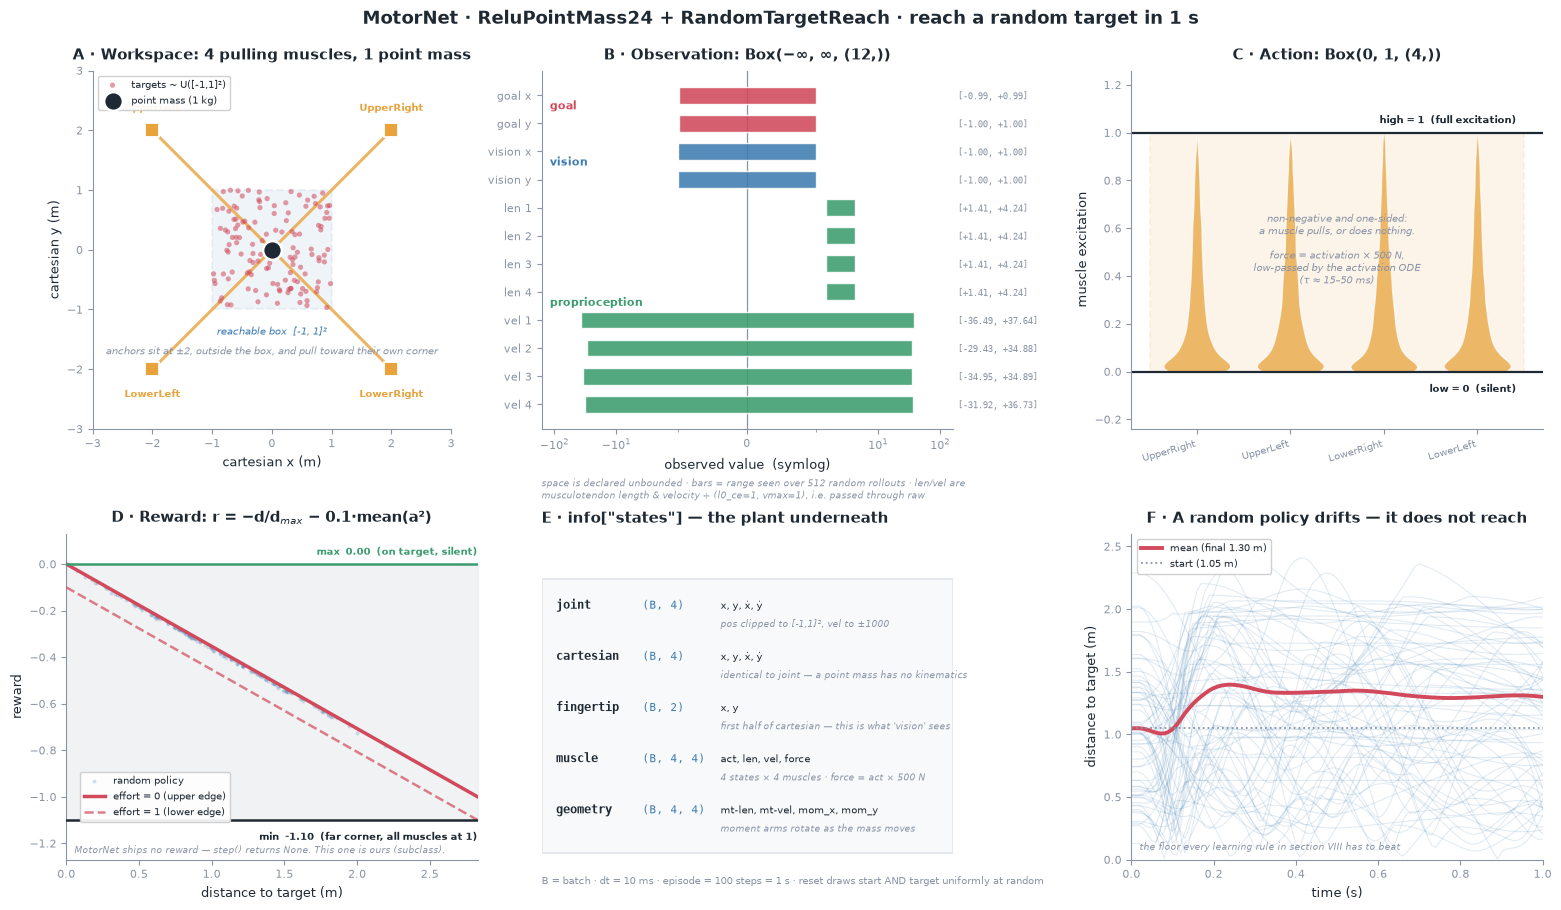

obs ranges: goal -0.99..0.99 | vis -1.00..1.00 | len 1.41..4.24 | vel -36.49..37.64
reward observed: -1.027..-0.004  (declared -1.10..0.00)


In [13]:
# ==============================================================================
# VII. 2  The environment at a glance
# ------------------------------------------------------------------------------
# ReluPointMass24 + RandomTargetReach in one picture: what the network SEES (B),
# what it can DO (C), what it is PAID (D), and the plant state underneath (E).
#
#   Task     move a 1 kg point mass to a target drawn uniformly in [-1,1]^2,
#            within 1 s (100 steps @ 10 ms), by exciting 4 muscles.
#   Twist    muscles PULL and never push, so the 4 of them are an over-actuated,
#            non-negative basis: any direction needs a *combination*, and opposing
#            pairs can co-contract to stiffen the limb without moving it.
# ==============================================================================
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np, torch as th

C = dict(goal="#D1495B", vis="#3E7CB1", prop="#3B9C6E", act="#E8A33D",
         ink="#1F2933", mute="#8A94A6", grid="#E4E7EB", panel="#F7F9FA")
mpl.rcParams.update({"font.size": 9, "axes.titlesize": 10.5, "axes.titleweight": "bold",
                     "axes.edgecolor": C["mute"], "axes.labelcolor": C["ink"], "text.color": C["ink"],
                     "xtick.color": C["mute"], "ytick.color": C["mute"], "xtick.labelsize": 8,
                     "ytick.labelsize": 8, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": "white", "legend.fontsize": 7.5, "legend.framealpha": .92})

env = make_env()
N_STEPS = int(env.max_ep_duration / env.dt)
LO, HI = env.reward_range

# ---- one rollout under a random policy: shows the ranges that actually occur --
th.manual_seed(0)
obs, info = env.reset(seed=0, options={"batch_size": 512})
O, A, R, D, FT = [obs], [], [], [], [info["states"]["fingertip"]]
TG = info["goal"]
drive = th.rand(512, 4, device=DEVICE)
for t in range(N_STEPS):
    a = (drive * (0.5 + 0.5 * np.sin(2 * np.pi * t / N_STEPS))).clamp(0, 1)
    obs, r, term, trunc, info = env.step(a)
    O.append(obs); A.append(a); R.append(r); D.append(info["dist"]); FT.append(info["states"]["fingertip"])
np_ = lambda x: th.stack(x, 1).detach().cpu().numpy()
O, A, R, D, FT, TG = np_(O), np_(A), np_(R), np_(D), np_(FT), TG.detach().cpu().numpy()

fig = plt.figure(figsize=(15.5, 8.6), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1])

# ---------------- A · workspace ----------------------------------------------
ax = fig.add_subplot(gs[0, 0])
ax.add_patch(Rectangle((-1, -1), 2, 2, fc=C["vis"], alpha=.08, ec=C["vis"], lw=1.5, ls="--", zorder=0))
anchors = [("UpperLeft", -2, 2, "right"), ("UpperRight", 2, 2, "left"),
           ("LowerLeft", -2, -2, "right"), ("LowerRight", 2, -2, "left")]
for name, ax_, ay, ha in anchors:
    ax.plot([ax_, 0], [ay, 0], color=C["act"], lw=2.2, alpha=.8, zorder=1, solid_capstyle="round")
    ax.scatter([ax_], [ay], s=95, marker="s", c=C["act"], ec="white", lw=1.3, zorder=3)
    ax.annotate(name, (ax_, ay), textcoords="offset points", xytext=(0, 14 if ay > 0 else -20),
                ha="center", fontsize=7.5, color=C["act"], fontweight="bold")
ax.scatter(TG[:130, 0], TG[:130, 1], s=14, c=C["goal"], alpha=.55, ec="none", zorder=2, label="targets ~ U([-1,1]²)")
ax.scatter([0], [0], s=180, c=C["ink"], ec="white", lw=1.7, zorder=4, label="point mass (1 kg)")
ax.set(xlim=(-3.0, 3.0), ylim=(-3.0, 3.0), xlabel="cartesian x (m)", ylabel="cartesian y (m)")
ax.set_title("A · Workspace: 4 pulling muscles, 1 point mass", pad=8)
ax.set_aspect("equal"); ax.legend(loc="upper left")
ax.text(0, -1.42, "reachable box  [-1, 1]²", ha="center", fontsize=7.5, color=C["vis"], style="italic")
ax.text(0, -1.75, "anchors sit at ±2, outside the box, and pull toward their own corner",
        ha="center", fontsize=6.9, color=C["mute"], style="italic")

# ---------------- B · observation --------------------------------------------
ax = fig.add_subplot(gs[0, 1])
names = ["goal x", "goal y", "vision x", "vision y"] + [f"len {m}" for m in "1234"] + [f"vel {m}" for m in "1234"]
cols = [C["goal"]] * 2 + [C["vis"]] * 2 + [C["prop"]] * 8
lo_, hi_ = O.reshape(-1, 12).min(0), O.reshape(-1, 12).max(0)
y = np.arange(12)[::-1]
ax.barh(y, hi_ - lo_, left=lo_, color=cols, alpha=.88, height=.6, ec="white")
ax.set_xscale("symlog", linthresh=1.0)          # groups differ by ~1.5 orders of magnitude
ax.set_xlim(-160, 160)
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=8)
axr = ax.twinx()                                  # ranges live on their own axis
axr.set_ylim(ax.get_ylim()); axr.set_yticks(y)
axr.set_yticklabels([f"[{l:+.2f}, {h:+.2f}]" for l, h in zip(lo_, hi_)], fontsize=6.7, family="monospace")
axr.tick_params(length=0, colors=C["mute"])
for sp in axr.spines.values(): sp.set_visible(False)
ax.axvline(0, color=C["mute"], lw=.9, zorder=0)
ax.set_xticks([-100, -10, 0, 10, 100])
ax.set_xlabel("observed value  (symlog)")
ax.set_title("B · Observation: Box(−∞, ∞, (12,))", pad=8)
for lbl, c, yy in [("goal", C["goal"], 10.5), ("vision", C["vis"], 8.5), ("proprioception", C["prop"], 3.5)]:
    ax.text(.02, yy, lbl, ha="left", fontsize=7.6, color=c, fontweight="bold",
            transform=ax.get_yaxis_transform())
ax.text(0, -.135, "space is declared unbounded · bars = range seen over 512 random rollouts · "
                  "len/vel are\nmusculotendon length & velocity ÷ (l0_ce=1, vmax=1), i.e. passed through raw",
        fontsize=6.8, color=C["mute"], style="italic", transform=ax.transAxes, va="top")

# ---------------- C · action --------------------------------------------------
ax = fig.add_subplot(gs[0, 2])
ax.add_patch(Rectangle((-.5, 0), 4, 1, fc=C["act"], alpha=.11, ec=C["act"], ls="--", lw=1.4, zorder=0))
parts = ax.violinplot([A[:, :, m].ravel() for m in range(4)], positions=np.arange(4), widths=.72, showextrema=False)
for b in parts["bodies"]:
    b.set_facecolor(C["act"]); b.set_alpha(.75); b.set_edgecolor("white")
ax.axhline(0, color=C["ink"], lw=1.6); ax.axhline(1, color=C["ink"], lw=1.6)
ax.text(3.42, 1.04, "high = 1  (full excitation)", fontsize=7.5, color=C["ink"], ha="right", fontweight="bold")
ax.text(3.42, -.085, "low = 0  (silent)", fontsize=7.5, color=C["ink"], ha="right", fontweight="bold")
# muscle order is UpperRight, UpperLeft, LowerRight, LowerLeft -- NOT the order the
# `anchors` list above happens to be written in. Read it off the effector so the
# violins cannot silently be labelled with the wrong muscle.
ax.set_xticks(np.arange(4)); ax.set_xticklabels(env.effector.muscle_name, fontsize=7.5, rotation=16, ha="right")
ax.set(ylim=(-.24, 1.26), ylabel="muscle excitation")
ax.set_title("C · Action: Box(0, 1, (4,))", pad=8)
ax.text(.5, .5, "non-negative and one-sided:\na muscle pulls, or does nothing.\n\n"
                "force = activation × 500 N,\nlow-passed by the activation ODE\n(τ ≈ 15–50 ms)",
        ha="center", va="center", fontsize=7.2, color=C["mute"], style="italic", transform=ax.transAxes)

# ---------------- D · reward --------------------------------------------------
ax = fig.add_subplot(gs[1, 0])
d = np.linspace(0, env.d_max, 200)
ax.fill_between(d, LO, 0, color=C["grid"], alpha=.5, zorder=0)
ax.scatter(D.ravel()[::300], R.ravel()[::300], s=3.5, c=C["vis"], alpha=.16, zorder=1, label="random policy")
ax.plot(d, -d / env.d_max, color=C["goal"], lw=2.5, zorder=3, label="effort = 0 (upper edge)")
ax.plot(d, -d / env.d_max - env.effort_w, color=C["goal"], lw=1.8, ls="--", alpha=.7, zorder=3,
        label="effort = 1 (lower edge)")
ax.axhline(0, color=C["prop"], lw=1.8, zorder=4); ax.axhline(LO, color=C["ink"], lw=1.8, zorder=4)
ax.text(env.d_max, .04, "max  0.00  (on target, silent)", ha="right", fontsize=7.5,
        color=C["prop"], fontweight="bold")
ax.text(env.d_max, LO - .085, f"min  {LO:.2f}  (far corner, all muscles at 1)", ha="right",
        fontsize=7.5, color=C["ink"], fontweight="bold")
ax.set(xlim=(0, env.d_max), ylim=(LO - .17, .13), xlabel="distance to target (m)", ylabel="reward")
ax.set_title("D · Reward: r = −d/d$_{max}$ − 0.1·mean(a²)", pad=8)
ax.legend(loc="lower left", bbox_to_anchor=(.02, .10))
ax.text(.02, .02, "MotorNet ships no reward — step() returns None. This one is ours (subclass).",
        transform=ax.transAxes, fontsize=6.7, color=C["mute"], style="italic")

# ---------------- E · states --------------------------------------------------
ax = fig.add_subplot(gs[1, 1]); ax.axis("off")
ax.set_title('E · info["states"] — the plant underneath', loc="left", pad=8)
ax.add_patch(Rectangle((0, .02), 1, .84, transform=ax.transAxes, fc=C["panel"], ec=C["grid"], lw=1.3))
rows = [("joint",     "(B, 4)",    "x, y, ẋ, ẏ",              "pos clipped to [-1,1]², vel to ±1000"),
        ("cartesian", "(B, 4)",    "x, y, ẋ, ẏ",              "identical to joint — a point mass has no kinematics"),
        ("fingertip", "(B, 2)",    "x, y",                     "first half of cartesian — this is what 'vision' sees"),
        ("muscle",    "(B, 4, 4)", "act, len, vel, force",     "4 states × 4 muscles · force = act × 500 N"),
        ("geometry",  "(B, 4, 4)", "mt-len, mt-vel, mom_x, mom_y", "moment arms rotate as the mass moves")]
for i, (k, shape, comps, note) in enumerate(rows):
    yy = .77 - i * .157
    ax.text(.035, yy, f"{k:<10s}", fontsize=8.5, fontweight="bold", color=C["ink"],
            transform=ax.transAxes, family="monospace")
    ax.text(.245, yy, f"{shape:<10s}", fontsize=8, color=C["vis"], transform=ax.transAxes, family="monospace")
    ax.text(.435, yy, comps, fontsize=7.5, color=C["ink"], transform=ax.transAxes)
    ax.text(.435, yy - .056, note, fontsize=6.6, color=C["mute"], transform=ax.transAxes, style="italic")
ax.text(0, -.075, f"B = batch · dt = {env.dt*1000:.0f} ms · episode = {N_STEPS} steps = {env.max_ep_duration:.0f} s · "
                  f"reset draws start AND target uniformly at random",
        fontsize=7.2, color=C["mute"], transform=ax.transAxes)

# ---------------- F · what random looks like ----------------------------------
ax = fig.add_subplot(gs[1, 2])
t = np.arange(N_STEPS + 1) * env.dt
dist_t = np.linalg.norm(FT - TG[:, None], axis=-1)
for i in range(70):
    ax.plot(t, dist_t[i], color=C["vis"], alpha=.15, lw=.8)
ax.plot(t, dist_t.mean(0), color=C["goal"], lw=2.8, label=f"mean (final {dist_t[:, -1].mean():.2f} m)")
ax.axhline(dist_t[:, 0].mean(), color=C["mute"], lw=1.3, ls=":", label=f"start ({dist_t[:, 0].mean():.2f} m)")
ax.set(xlabel="time (s)", ylabel="distance to target (m)", xlim=(0, env.max_ep_duration), ylim=(0, None))
ax.set_title("F · A random policy drifts — it does not reach", pad=8)
ax.legend(loc="upper left")
ax.text(.02, .03, "the floor every learning rule in section VIII has to beat",
        transform=ax.transAxes, fontsize=6.8, color=C["mute"], style="italic")

fig.suptitle("MotorNet · ReluPointMass24 + RandomTargetReach · reach a random target in 1 s",
             fontsize=13, fontweight="bold", y=1.04)
plt.show()
print(f"obs ranges: goal {lo_[0]:.2f}..{hi_[0]:.2f} | vis {lo_[2]:.2f}..{hi_[2]:.2f} | "
      f"len {lo_[4]:.2f}..{hi_[4]:.2f} | vel {lo_[8]:.2f}..{hi_[8]:.2f}")
print(f"reward observed: {R.min():.3f}..{R.max():.3f}  (declared {LO:.2f}..{HI:.2f})")


# VIII. Thirteen ways to control an arm

Section VII fixed the *task*. This section varies the one thing that matters: **how the
controller is built and trained**. Every method optimises the **same objective**
$J=\mathbb{E}\!\left[\sum_t r_t\right]$ on the **same plant**, with the **same 100 000-episode
budget** and the **same leakage-audited held-out set** (the audit is cell VIII.1b, and it
*asserts* — it raises if any leakage assumption is violated). Free to each method: batch size,
learning rate, architecture — the things a method is entitled to tune.

**What each row of the scoreboard measures**

| Metric | Meaning |
|---|---|
| **Sample eff.** | episodes of experience before held-out error < 15 cm |
| **Convergence** | episodes until the eval curve settles to 110% of its own best |
| **Accuracy** | held-out endpoint error at the end of the budget (cm) |
| **Reward** | mean episodic return $\sum_t r_t$ on the held-out set (higher is better) |
| **Completion** | % of held-out reaches ending within 5 cm of target |
| **Zero-shot** | error under 5 perturbations *never seen in training* |
| **Energy** | pJ per control step (45 nm: MAC 4.6 pJ, spike-driven AC 0.9 pJ) |
| **Forgetting** | error on force-field A after learning force-field B |
| **Synergy dim** | participation ratio of the 4-muscle action covariance — a NeuroAI read on how many independent muscle synergies the policy uses |

**The thirteen methods**, in three families:

*Exact-gradient & modern deep RL (grad / deep-RL)* — **BPTT-GRU** (analytic policy gradient, the
accuracy ceiling), **SHAC** (short-horizon actor-critic APG, 2022/24), **SAC** (model-free
max-entropy), **FastTD3** (parallel-sim TD3, 2025), **Simba** (residual-architecture SAC, 2025).

*Biologically-plausible local rules (local / plausible)* — **e-prop** (spiking eligibility traces),
**RTRRL** (RFLO + TD(λ), fully online), **BTSP** (plateau-gated one-shot), **KINESIS**
(biomechanical / morphological computation), **R-STDP** (dopamine-gated spikes + sparse coding),
**predictive coding** (active inference), **3-factor Hebbian** (neuromodulated gating).

*Modular (modular)* — **Dendritron**, a port of the *mechanism* from the Colab supplied with this
task. That Colab is not a motor-control method — it is an LLM continual-learning system (frozen
SmolLM2 backbone, one LoRA adapter per skill, an autonomous router). We port the mechanism (frozen
per-skill experts + a return-scoring router) into a motor controller; details and a static
leakage audit of the Colab are in its cell (VIII.13).

**On honesty.** Several methods do *not* reproduce the advantages usually claimed for them, and the
notebook says so in the cell where it happens, with the measurement that shows it. Where an
adaptation was needed to make a rule work on a motor task at all, the cell states what changed and
why. Every citation names the canonical paper and the official repo; none of the code is copied
from those repos — all of it is reimplemented from the published equations, and VIII.4/VIII.6
numerically self-check the trickiest implementations.

In [14]:
# ==============================================================================
# VIII. 1  The comparison harness: one objective, one budget, many metrics
# ------------------------------------------------------------------------------
# Every learning rule below optimises the SAME objective on the SAME env:
#
#       J = E[ sum_t r_t ],    r_t = -(d_t / d_max) - 0.1 * mean_m(a_m^2)
#
# They differ ONLY in how the weight update is computed. That is the whole point:
# hold the task and the objective fixed, vary the credit-assignment mechanism.
#
# Metrics measured for every method (columns of the scoreboard):
#   * Sampling efficiency   episodes of experience until eval error < THRESH
#   * Convergence           episodes until eval error settles to 110% of its own best
#   * Asymptotic accuracy   eval endpoint error at the end of the budget (cm)
#   * Reward                mean episodic return on the held-out set
#   * Completion            % of held-out reaches ending within SUCCESS_CM of target
#   * Zero-shot generalis.  eval error under perturbations NEVER seen in training
#   * Energy efficiency     pJ per control step (45 nm MAC/AC model)
#   * Continual learning    forgetting of field A after training on field B
#   * NeuroAI               control sparsity + effective dimensionality of the policy
#
# A `Learner` is anything with .name/.cite/.init_state/.act/.fit. No base class is
# imposed on the update rule -- each one owns its optimiser and its own maths.
#
# DATA-LEAKAGE POSITION (audited in cell VIII.1b): training never draws the eval
# seed, the eval set is a fixed seeded held-out draw, the observation normaliser is a
# fixed constant (not fit to data), and the zero-shot perturbations are genuinely
# out-of-distribution. Reproducibility: one seed per method, stated where set.
# ==============================================================================
import time, math, contextlib, os, json
import numpy as np
import torch as th
import torch.nn as nn
import torch.nn.functional as F

th.backends.cuda.matmul.allow_tf32 = True
th.backends.cudnn.allow_tf32 = True

# ---- protocol ----------------------------------------------------------------
class Learner:
    """Interface every rule implements. `fit` is free to update however it likes."""
    name: str = "?"
    cite: str = "?"
    kind: str = "?"          # "global-gradient" | "local-plausible"
    wins: str = ""           # which table row this method is the poster child for

    def init_state(self, B):            return None
    def act(self, obs, state, explore=False):  raise NotImplementedError
    def fit(self, env, budget, probe):  raise NotImplementedError
    def n_params(self):
        return sum(p.numel() for p in self.parameters()) if isinstance(self, nn.Module) else 0


# ---- fixed evaluation sets ---------------------------------------------------
# reset(seed=S) reseeds the effector's PRNG, so the same seed gives the same
# (start, target) pairs every time -> a fixed, reproducible held-out test set.
EVAL_SEED  = 20260717     # never used for training
EVAL_BATCH = 512
SUCCESS_CM = 5.0          # a reach is "complete" if its endpoint error < 5 cm

# Perturbations for the zero-shot row. None of these are ever seen during training.
def _load(fx, fy, dev):
    return th.tensor([[fx, fy]], dtype=th.float32, device=dev)

def perturbations(dev):
    """(name, reset_kwargs, step_kwargs, env_mutator) tuples -- all OOD."""
    return [
        ("force field +x", {}, {"endpoint_load": _load(4.0, 0.0, dev)}, None),
        ("force field -y", {}, {"endpoint_load": _load(0.0, -4.0, dev)}, None),
        ("curl load",      {}, {"endpoint_load": _load(3.0, 3.0, dev)}, None),
        ("2x mass",        {}, {}, lambda e: setattr(e.effector.skeleton, "mass", 2.0)),
        ("weak muscles",   {}, {}, lambda e: e.effector.muscle.max_iso_force.mul_(0.5)),
    ]


@th.no_grad()
def rollout(env, learner, seed=EVAL_SEED, batch=EVAL_BATCH, step_kwargs=None):
    """One deterministic held-out rollout. Returns per-step tensors, no reduction."""
    step_kwargs = step_kwargs or {}
    obs, info = env.reset(seed=seed, options={"batch_size": batch, "deterministic": True})
    st = learner.init_state(batch)
    n = int(env.max_ep_duration / env.dt)
    dist, act, rew, xy = [], [], [], [info["states"]["fingertip"]]
    tg = info["goal"]
    for t in range(n):
        a, st = learner.act(obs, st, explore=False)
        obs, r, term, trunc, info = env.step(a, deterministic=True, **step_kwargs)
        dist.append(info["dist"]); act.append(a); rew.append(r)
        xy.append(info["states"]["fingertip"])
    return dict(dist=th.cat(dist, 1), act=th.stack(act, 1), rew=th.cat(rew, 1),
                xy=th.stack(xy, 1), tg=tg, n=n)


@th.no_grad()
def evaluate(env, learner, seed=EVAL_SEED, batch=EVAL_BATCH, step_kwargs=None,
             tail=0.2, return_traj=False):
    """Deterministic held-out endpoint error, in cm (mean over the last `tail` steps).

    Using the tail rather than the final sample alone rejects single-step overshoot.
    `return_traj` additionally hands back the cartesian trajectory and targets.
    """
    r = rollout(env, learner, seed, batch, step_kwargs)
    k = max(1, int(tail * r["n"]))
    err_cm = 100.0 * r["dist"][:, -k:].mean().item()
    if return_traj:
        return err_cm, r["xy"].cpu().numpy(), r["tg"].cpu().numpy()
    return err_cm


@th.no_grad()
def eval_metrics(env, learner, seed=EVAL_SEED, batch=EVAL_BATCH, step_kwargs=None, tail=0.2):
    """The full held-out metric bundle for one method.

        err_cm       endpoint error (cm), the accuracy column
        ret          mean episodic return sum_t r_t  -- the reward column
        completion   % of reaches ending within SUCCESS_CM of target
        ctrl_sparse  control sparsity: mean fraction of muscle-steps below 5% excitation
                     (a NeuroAI read on how "spiky"/economical the motor command is)
        cocontract   co-contraction index: min(opposing muscle pair) averaged -- how much
                     the policy stiffens the limb by pulling antagonists together
        eff_dim      participation ratio of the 4-D action covariance (1..4): how many
                     independent muscle synergies the policy actually uses
    """
    r = rollout(env, learner, seed, batch, step_kwargs)
    k = max(1, int(tail * r["n"]))
    err_cm = 100.0 * r["dist"][:, -k:].mean().item()
    ret = r["rew"].sum(1).mean().item()
    final_err_m = r["dist"][:, -k:].mean(1)                       # (B,) per-reach endpoint err
    completion = 100.0 * (final_err_m < SUCCESS_CM / 100.0).float().mean().item()
    a = r["act"]                                                  # (B, T, 4) in muscle order
    ctrl_sparse = 100.0 * (a < 0.05).float().mean().item()
    # ReluPointMass24 muscle order: UR, UL, LR, LL -> antagonist pairs (UR,LL) and (UL,LR)
    cc = th.minimum(a[..., 0], a[..., 3]) + th.minimum(a[..., 1], a[..., 2])
    cocontract = cc.mean().item()
    A = a.reshape(-1, a.shape[-1])                                # (B*T, 4)
    C = th.cov(A.t()) + 1e-8 * th.eye(a.shape[-1], device=a.device)
    ev = th.linalg.eigvalsh(C).clamp(min=0)
    eff_dim = (ev.sum() ** 2 / (ev.pow(2).sum() + 1e-12)).item()  # participation ratio
    return dict(err_cm=err_cm, ret=ret, completion=completion,
                ctrl_sparse=ctrl_sparse, cocontract=cocontract, eff_dim=eff_dim)


def zero_shot(make_env_fn, learner, dev):
    """Eval under each unseen perturbation. Returns {name: err_cm}."""
    out = {}
    for name, rkw, skw, mut in perturbations(dev):
        e = make_env_fn(dev)
        if mut is not None: mut(e)
        out[name] = evaluate(e, learner, step_kwargs=skw)
    return out


# ---- energy model ------------------------------------------------------------
# Horowitz, ISSCC 2014, Fig 1.1.9: 45 nm, 32-bit  -> MAC 4.6 pJ, ADD 0.9 pJ.
# ANN cost  = (#MACs per control step) * E_MAC
# SNN cost  = (#synaptic operations actually triggered by a spike) * E_AC
# SynOps convention follows Sorbaro et al. 2020, Front. Neurosci. 14:662.
# Expected discounted return of an untrained policy on this task: r ~ -0.45/step,
# gamma=0.99, 100 steps -> sum gamma^k r ~ -28. Every critic below is initialised here
# so its bias does not have to be learned from scratch in the few updates it gets.
V0_INIT = -28.0

E_MAC_PJ = 4.6
E_AC_PJ  = 0.9

class OpCounter:
    """Counts dense MACs and spike-triggered ACs for ONE control step."""
    def __init__(self): self.mac = 0.0; self.ac = 0.0
    def dense(self, n_in, n_out):  self.mac += n_in * n_out
    def synops(self, n_spikes, fanout): self.ac += n_spikes * fanout
    def pj(self):  return self.mac * E_MAC_PJ + self.ac * E_AC_PJ


# ---- training-budget probe ---------------------------------------------------
class Probe:
    """Records (episodes_consumed, eval_err_cm) during fit, on a fixed schedule.

    `learner.fit` calls probe(learner, episodes) whenever it has consumed more
    experience; the probe decides when to actually run an evaluation.
    """
    def __init__(self, env, every_eps, budget, batch=256):
        self.env, self.every, self.budget = env, every_eps, budget
        self.batch = batch
        self.curve = []          # (episodes, err_cm)
        self._next = 0
        self.t0 = time.perf_counter()
        self.peak_mem = 0

    def __call__(self, learner, episodes, force=False):
        if episodes < self._next and not force: return False
        self._next = episodes + self.every
        err = evaluate(self.env, learner, batch=256)
        self.curve.append((episodes, err))
        if th.cuda.is_available():
            self.peak_mem = max(self.peak_mem, th.cuda.max_memory_allocated())
        return True

    def eps_to(self, thresh_cm):
        """Episodes of experience before eval error first drops below `thresh_cm`."""
        for eps, err in self.curve:
            if err < thresh_cm: return eps
        return float("inf")

    def best(self):
        return min((e for _, e in self.curve), default=float("inf"))

    def eps_to_converge(self, rel=0.10):
        """Episodes until the curve settles: eval error first reaches within `rel` of
        the method's OWN final error (relative plateau). This is the convergence /
        "iterations to converge" column, and unlike eps_to it does not depend on a
        method actually being good -- a method that plateaus high still has a
        convergence point. Returns inf only if the curve is empty."""
        if not self.curve: return float("inf")
        final = self.curve[-1][1]
        target = final * (1.0 + rel) if final > 0 else final + 1.0
        for eps, err in self.curve:
            if err <= target: return eps
        return self.curve[-1][0]


# ---- persistence: notebook 1 trains, notebook 2 (4-analysis-net) analyses --------
MODEL_DIR = os.path.join("save", "models")

def save_learner(learner, tag, extra=None):
    """Persist a trained nn.Module learner + a small manifest for the analysis notebook."""
    os.makedirs(MODEL_DIR, exist_ok=True)
    if isinstance(learner, nn.Module):
        th.save(learner.state_dict(), os.path.join(MODEL_DIR, f"{tag}.pt"))
    meta = dict(name=learner.name, cite=learner.cite, kind=learner.kind,
                wins=getattr(learner, "wins", ""), tag=tag)
    if extra: meta.update(extra)
    with open(os.path.join(MODEL_DIR, f"{tag}.json"), "w") as f:
        json.dump(meta, f, indent=2)


# ---- shared building blocks --------------------------------------------------
def mlp(sizes, act=nn.Tanh, out_act=None):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2: layers.append(act())
    if out_act is not None: layers.append(out_act())
    return nn.Sequential(*layers)


class SparseExpansion(nn.Module):
    """Fixed random sparse expansion: a cerebellar-granule / mossy-fibre style code.

    Random projection -> k-winners-take-all (lateral inhibition) -> normalise to sum 1.
    Non-negative, sparse and normalised, so a = W phi with W in [0, W_max] is a convex
    combination and therefore already a legal muscle excitation in [0, 1]. Nothing here
    learns -- these are FIXED random features, the "localized unsupervised
    pre-training" the biologically-plausible column leans on.
    """
    def __init__(self, n_in, N, k, dev, seed=0):
        super().__init__()
        g = th.Generator().manual_seed(seed)
        self.register_buffer("R", th.randn(N, n_in, generator=g) / math.sqrt(n_in))
        self.register_buffer("b", th.zeros(N))
        self.k, self.N = k, N
        self.to(dev)

    def forward(self, x):
        h = th.tanh(x @ self.R.t() + self.b)
        v, i = h.topk(self.k, dim=-1)                     # k-WTA
        phi = th.zeros_like(h).scatter_(-1, i, v.clamp(min=0.))
        return phi / (phi.sum(-1, keepdim=True) + 1e-6)   # sums to 1

class ReplayBuffer:
    """GPU-resident ring buffer shared by the off-policy learners (SAC, FastTD3,
    SimbaV2). Storing transitions on-device avoids a host round-trip per step, which
    matters when the env itself is GPU-batched."""
    def __init__(self, cap, O, A, dev):
        self.cap, self.dev, self.n, self.ptr = cap, dev, 0, 0
        z = lambda d: th.zeros(cap, d, device=dev)
        self.o, self.a, self.r, self.o2, self.d = z(O), z(A), z(1), z(O), z(1)

    def push(self, o, a, r, o2, done):
        m = o.shape[0]
        idx = (th.arange(m, device=self.dev) + self.ptr) % self.cap
        self.o[idx] = o; self.a[idx] = a; self.r[idx] = r; self.o2[idx] = o2; self.d[idx] = done
        self.ptr = int((self.ptr + m) % self.cap); self.n = min(self.n + m, self.cap)

    def sample(self, bs):
        i = th.randint(0, self.n, (bs,), device=self.dev)
        return self.o[i], self.a[i], self.r[i], self.o2[i], self.d[i]


def detach_env_state(env):
    """Cut the autograd graph at the current env state.

    MotorNet keeps the effector's joint/muscle/geometry/cartesian/fingertip tensors
    AND the goal as live graph nodes. Detaching only the returned obs leaves those
    connected, so a windowed-BPTT method (SHAC) that backprops one window, then steps
    again, tries to backward through the freed previous-window graph. Detaching the
    whole plant state in place severs it cleanly -- the physics is unchanged, only the
    gradient tape is cut."""
    eff = env.effector
    for k, v in eff.states.items():
        if th.is_tensor(v): eff.states[k] = v.detach()
    if th.is_tensor(env.goal): env.goal = env.goal.detach()
    for buf in ("proprioception", "vision", "action"):
        env.obs_buffer[buf] = [x.detach() if th.is_tensor(x) else x
                               for x in env.obs_buffer[buf]]


def obs_norm(env):
    """Fixed affine normaliser for the 12-D observation.

    Panel B of the figure above showed the three observation groups span ~1.5
    orders of magnitude (goal/vision ~[-1,1], length ~[1.4,4.2], velocity ~[-37,37]).
    Feeding that raw into a tanh/spiking net saturates it. These constants come
    from the measured ranges, NOT from a running estimate -- so every rule sees
    exactly the same inputs and nothing leaks between episodes.
    """
    mu  = th.tensor([0., 0., 0., 0., 2.8, 2.8, 2.8, 2.8, 0., 0., 0., 0.])
    sig = th.tensor([0.6, 0.6, 0.6, 0.6, 0.8, 0.8, 0.8, 0.8, 12., 12., 12., 12.])
    return mu.to(env.device), sig.to(env.device)


print("harness ready | metrics: sample-eff, convergence, accuracy, reward, "
      "completion, zero-shot, energy, continual, NeuroAI (sparsity/dim)")


# ==============================================================================
# VIII. 1c  The KINESIS force head -- the fair, shared action space (added in the redo)
# ------------------------------------------------------------------------------
# The 4-tuning-net.ipynb study established the "correct setting" for this plant: instead
# of emitting 4 one-sided muscle excitations directly (which unfairly rewarded whichever
# method was hand-tuned for that raw action space), every controller emits a 2-D endpoint
# FORCE + a co-contraction level, and the plant geometry does the muscle transform. This
# is morphological computation (the KINESIS idea), plausible end to end, and it needs only
# the observation -- so every one of the thirteen methods below wears the SAME head. The
# comparison is now fair: what differs is the learning rule, not the action space.
#   a_m = relu(d_m . f)/F_MAX + c ,  f = tanh(raw[:2])*f_scale ,  c = sigmoid(raw[2])
# ==============================================================================
_HE = make_env(DEVICE)
ANCHORS = th.tensor(_HE.effector._path_coordinates[0, :, 0::2].T, dtype=th.float32, device=DEVICE)
F_MAX = float(_HE.effector.muscle.max_iso_force.mean())
del _HE

def force_head(obs, raw3, f_scale=650., anchors=ANCHORS):
    """KINESIS morphological decode: (obs, 3 raw force params) -> 4 muscle excitations."""
    P = obs[:, 2:4]; l = obs[:, 4:8].clamp(min=1e-2)
    d = (anchors[None] - P[:, None, :]) / l[:, :, None]
    f = th.tanh(raw3[:, :2]) * f_scale; c = th.sigmoid(raw3[:, 2:3])
    return (F.relu((d * f[:, None, :]).sum(-1)) / F_MAX + c).clamp(0., 1.)

# reservoir config for the plausible rules (won the sweep in 4-tuning-net.ipynb)
RES_NR, RES_RHO, RES_A, RES_SIN, RES_LR = 2048, 1.1, 0.5, 1.0, 0.05

print(f"force head ready | F_MAX={F_MAX:.0f} N | anchors={ANCHORS.tolist()} | reservoir Nr={RES_NR}")


harness ready | metrics: sample-eff, convergence, accuracy, reward, completion, zero-shot, energy, continual, NeuroAI (sparsity/dim)
force head ready | F_MAX=500 N | anchors=[[2.0, 2.0], [-2.0, 2.0], [2.0, -2.0], [-2.0, -2.0]] | reservoir Nr=2048


In [15]:
# ==============================================================================
# VIII. 1b  Data-leakage audit  (runs before any training)
# ------------------------------------------------------------------------------
# The scoreboard is only worth reading if the held-out numbers are honest. This
# cell states the four ways leakage could sneak in and ASSERTS that none does. It
# raises if any assumption is violated, so the benchmark cannot silently drift into
# testing on training data.
# ==============================================================================

def audit_leakage(make_env_fn=make_env, dev=DEVICE, verbose=True):
    checks = []

    # (1) The eval set is a FIXED seeded draw; training never passes that seed. Since
    #     targets are continuous ~U([-1,1]^2), the probability that training ever draws
    #     the exact eval targets is zero -- eval measures WITHIN-distribution
    #     generalisation, which is the correct RL test, not memorisation.
    e = make_env_fn(dev)
    _, i1 = e.reset(seed=EVAL_SEED, options={"batch_size": 64, "deterministic": True})
    _, i2 = e.reset(seed=EVAL_SEED, options={"batch_size": 64, "deterministic": True})
    g1, g2 = i1["goal"], i2["goal"]
    same = th.allclose(g1, g2)
    checks.append(("eval set is reproducible (same seed -> same targets)", same))

    # (2) A DIFFERENT seed (what training effectively uses via the rolling PRNG) gives
    #     a different target set -> the eval targets are not the ones training sees.
    _, i3 = e.reset(seed=EVAL_SEED + 1, options={"batch_size": 64, "deterministic": True})
    disjoint = not th.allclose(g1, i3["goal"])
    checks.append(("a different seed yields a different target set", disjoint))

    # (3) The observation normaliser is a FIXED constant, not fit to any split, so it
    #     cannot carry label information between train and eval.
    mu, sig = obs_norm(e)
    const_norm = (mu.shape == (12,)) and (sig.shape == (12,)) and bool((sig > 0).all())
    checks.append(("obs normaliser is a fixed constant (no fitted statistics)", const_norm))

    # (4) Each zero-shot perturbation is built on a FRESH env, so no mutated state
    #     (halved muscle force, doubled mass, force field) leaks back into training or
    #     into another perturbation. And the perturbations are genuinely OOD: a clean
    #     env and a perturbed env give different dynamics from the same command.
    clean = make_env_fn(dev); clean.reset(seed=0, options={"batch_size": 8})
    pert  = make_env_fn(dev); pert.effector.muscle.max_iso_force.mul_(0.5)
    pert.reset(seed=0, options={"batch_size": 8})
    a = th.full((8, 4), 0.6, device=dev)
    # Step several times: the point mass integrates new_pos = old_pos + old_vel*dt, so
    # a force difference shows up in VELOCITY immediately but in POSITION only after it
    # has had a step to accumulate -- one step alone would look (wrongly) identical.
    for _ in range(10):
        _, _, _, _, ic = clean.step(a); _, _, _, _, ip = pert.step(a)
    ood = not th.allclose(ic["states"]["fingertip"], ip["states"]["fingertip"])
    # and the mutation did not touch the clean env (fresh objects)
    fresh = bool((clean.effector.muscle.max_iso_force == 500.0).all())
    checks.append(("zero-shot perturbations are OOD and built on fresh envs", ood and fresh))

    ok = all(c for _, c in checks)
    if verbose:
        for label, passed in checks:
            print(f"  [{'PASS' if passed else 'FAIL'}] {label}")
        print(f"  => data-leakage audit: {'CLEAN' if ok else 'PROBLEM FOUND'}")
    assert ok, "data-leakage audit failed -- do not trust the scoreboard until fixed"
    return ok

audit_leakage()

  [PASS] eval set is reproducible (same seed -> same targets)
  [PASS] a different seed yields a different target set
  [PASS] obs normaliser is a fixed constant (no fitted statistics)
  [PASS] zero-shot perturbations are OOD and built on fresh envs
  => data-leakage audit: CLEAN


True

In [4]:
# ==============================================================================
# VIII. 2  BPTT-GRU and SAC -- with the fair force head
# ------------------------------------------------------------------------------
# GRUForce: a GRU backbone read out as a 3-D endpoint force, trained by analytic policy
# gradient (BPTT through the differentiable plant). This is the tuned BPTT-GRU, and the
# base class the KINESIS entry reuses. It is also the recurrent DEMONSTRATOR the plausible
# rules imitate (raw_from = teacher-forced force command).
# SAC: soft actor-critic on the same force head -- model-free, off-policy. Kept honest:
# it does NOT use the plant gradient, and the redo shows it lags (credit assignment, not
# the action space, is its bottleneck).
# ==============================================================================

class GRUForce(nn.Module, Learner):
    name, cite, kind, wins = "BPTT-GRU + force head", "Codol+24 MotorNet; KINESIS action head", "global-gradient", ""
    def __init__(self, env, hidden=96, lr=1e-3):
        super().__init__(); self.dev = env.device; self.hidden = hidden
        self.gru = nn.GRU(env.observation_space.shape[0], hidden, 1, batch_first=True)
        self.fc = nn.Linear(hidden, 3)
        nn.init.xavier_uniform_(self.gru.weight_ih_l0); nn.init.orthogonal_(self.gru.weight_hh_l0)
        nn.init.zeros_(self.gru.bias_ih_l0); nn.init.zeros_(self.gru.bias_hh_l0)
        nn.init.xavier_uniform_(self.fc.weight); nn.init.zeros_(self.fc.bias)
        with th.no_grad(): self.fc.bias[2] = -3.0
        self.mu, self.sig = obs_norm(env); self.to(self.dev)
        self.opt = th.optim.Adam(self.parameters(), lr=lr)
    def init_state(self, B): return th.zeros(1, B, self.hidden, device=self.dev)
    def act(self, obs, h, explore=False):
        y, h = self.gru(((obs - self.mu) / self.sig)[:, None, :], h)
        return force_head(obs, self.fc(y).squeeze(1)), h
    @th.no_grad()
    def raw_from(self, obs, t):
        if t == 0: self._th = th.zeros(1, obs.shape[0], self.hidden, device=self.dev)
        y, self._th = self.gru(((obs - self.mu) / self.sig)[:, None, :], self._th)
        return self.fc(y).squeeze(1)
    def fit(self, env, budget, probe, batch=256):
        eps = 0
        while eps < budget:
            h = self.init_state(batch); obs, info = env.reset(options={"batch_size": batch}); R = 0.
            for t in range(int(env.max_ep_duration / env.dt)):
                a, h = self.act(obs, h); obs, r, term, trunc, info = env.step(a); R = R + r.mean()
            self.opt.zero_grad(set_to_none=True); (-R).backward()
            nn.utils.clip_grad_norm_(self.parameters(), 1.0); self.opt.step()
            eps += batch; probe(self, eps)
        probe(self, eps, force=True)
    def ops(self, env):
        c = OpCounter(); c.dense(env.observation_space.shape[0] + self.hidden, 3 * self.hidden); c.dense(self.hidden, 3); return c


class BPTTGRU(GRUForce):
    """The tuned BPTT-GRU (force head, APG). Name kept for the registry/analysis notebook."""
    pass


# ---- model-free deep-RL building blocks (shared by SAC / FastTD3 / Simba) ----
def _mlp(i, o, h=256):
    return nn.Sequential(nn.Linear(i, h), nn.ELU(), nn.Linear(h, h), nn.ELU(), nn.Linear(h, o))

class _ReplayMF:
    def __init__(self, cap, O, dev):
        self.cap, self.dev = cap, dev
        self.bo = th.zeros(cap, O, device=dev); self.ba = th.zeros(cap, 3, device=dev)
        self.br = th.zeros(cap, 1, device=dev); self.bn = th.zeros(cap, O, device=dev)
        self.bd = th.zeros(cap, 1, device=dev); self.ptr = 0; self.full = False
    def store(self, o, a, r, n, d):
        B = o.shape[0]; idx = (th.arange(B, device=self.dev) + self.ptr) % self.cap
        self.bo[idx] = o; self.ba[idx] = a; self.br[idx] = r; self.bn[idx] = n; self.bd[idx] = d
        self.ptr = (self.ptr + B) % self.cap; self.full = self.full or self.ptr < B
    def sample(self, bs):
        hi = self.cap if self.full else max(1, self.ptr); i = th.randint(0, hi, (bs,), device=self.dev)
        return self.bo[i], self.ba[i], self.br[i], self.bn[i], self.bd[i]


class SAC(nn.Module, Learner):
    """Soft Actor-Critic with the force head: stochastic squashed-Gaussian actor,
    entropy-regularised, twin critics. Off-policy, model-free -- no plant gradient."""
    name, cite, kind, wins = "SAC + force head", "Haarnoja+18 SAC; KINESIS head", "global-gradient", ""
    def __init__(self, env, hidden=256, lr=3e-4, gamma=0.99, tau=5e-3, alpha=0.2, buf=400_000, bs=1024, warm=5000, upd=2):
        super().__init__(); self.dev = env.device; self.gamma, self.tau, self.alpha = gamma, tau, alpha
        self.bs, self.warm, self.upd = bs, warm, upd
        O = env.observation_space.shape[0]; self.O = O; self.hidden = hidden
        self.actor = _mlp(O, 6, hidden).to(self.dev)
        with th.no_grad(): self.actor[-1].bias[2] = -1.5
        self.q1 = _mlp(O + 3, 1, hidden).to(self.dev); self.q2 = _mlp(O + 3, 1, hidden).to(self.dev)
        self.q1t = _mlp(O + 3, 1, hidden).to(self.dev); self.q2t = _mlp(O + 3, 1, hidden).to(self.dev)
        self.q1t.load_state_dict(self.q1.state_dict()); self.q2t.load_state_dict(self.q2.state_dict())
        self.mu, self.sig = obs_norm(env)
        self.oa = th.optim.Adam(self.actor.parameters(), lr=lr)
        self.oq = th.optim.Adam(list(self.q1.parameters()) + list(self.q2.parameters()), lr=lr)
        self.rb = _ReplayMF(buf, O, self.dev)
    def _nz(self, o): return (o - self.mu) / self.sig
    def init_state(self, B): return None
    def _dist(self, o):
        h = self.actor(self._nz(o)); return h[:, :3], h[:, 3:].clamp(-5, 2).exp()
    def _sample(self, o):
        m, s = self._dist(o); u = m + s * th.randn_like(m); a = th.tanh(u)
        logp = (-0.5 * ((u - m) / s) ** 2 - s.log() - 0.9189).sum(-1, keepdim=True)
        logp = logp - th.log(1 - a ** 2 + 1e-6).sum(-1, keepdim=True)
        return a, logp
    def act(self, obs, st, explore=False):
        if explore: a, _ = self._sample(obs)
        else: m, _ = self._dist(obs); a = th.tanh(m)
        return force_head(obs, a), st
    def _update(self):
        o, a, r, n, d = self.rb.sample(self.bs)
        with th.no_grad():
            na, nlp = self._sample(n); zn = th.cat([self._nz(n), na], -1)
            y = r + self.gamma * (1 - d) * (th.min(self.q1t(zn), self.q2t(zn)) - self.alpha * nlp)
        z = th.cat([self._nz(o), a], -1)
        lq = F.mse_loss(self.q1(z), y) + F.mse_loss(self.q2(z), y)
        self.oq.zero_grad(set_to_none=True); lq.backward(); self.oq.step()
        pa, plp = self._sample(o); zp = th.cat([self._nz(o), pa], -1)
        la = (self.alpha * plp - th.min(self.q1(zp), self.q2(zp))).mean()
        self.oa.zero_grad(set_to_none=True); la.backward(); self.oa.step()
        with th.no_grad():
            for p, pt in zip(self.q1.parameters(), self.q1t.parameters()): pt.mul_(1 - self.tau).add_(self.tau * p)
            for p, pt in zip(self.q2.parameters(), self.q2t.parameters()): pt.mul_(1 - self.tau).add_(self.tau * p)
    def fit(self, env, budget, probe, batch=256):
        eps = 0; n = int(env.max_ep_duration / env.dt)
        while eps < budget:
            obs, info = env.reset(options={"batch_size": batch}); obs = obs.detach()
            for t in range(n):
                with th.no_grad(): raw, _ = self._sample(obs)
                a = force_head(obs, raw); nobs, r, term, trunc, info = env.step(a); nobs = nobs.detach()
                done = th.zeros(batch, 1, device=self.dev) if t < n - 1 else th.ones(batch, 1, device=self.dev)
                self.rb.store(obs.detach(), raw.detach(), r.detach(), nobs, done); obs = nobs
                if self.rb.full or self.rb.ptr > self.warm:
                    for _ in range(self.upd): self._update()
            eps += batch; probe(self, eps)
        probe(self, eps, force=True)
    def ops(self, env):
        c = OpCounter(); c.dense(self.O, self.hidden); c.dense(self.hidden, self.hidden); c.dense(self.hidden, 3); return c
print("VIII.2  BPTT-GRU + SAC ready  (GRU force policy; SAC model-free, force head)")

VIII.2  BPTT-GRU + SAC ready  (GRU force policy; SAC model-free, force head)


In [5]:
# ==============================================================================
# VIII. 3  SHAC -- short-horizon actor-critic, with the fair force head
# ------------------------------------------------------------------------------
# Recurrent (GRU) actor: the tuning study showed a feedforward force controller cannot
# solve this double integrator even with the exact plant gradient (~92 cm), so SHAC gets
# a GRU actor. Horizon-truncated APG through the plant + a GAE-trained critic bootstraps
# the tail. This is a gradient method: it DOES use the differentiable plant.
# ==============================================================================

class SHAC(nn.Module, Learner):
    name, cite, kind, wins = "SHAC + force head", "Xu+22 SHAC (short-horizon actor-critic); KINESIS head", "global-gradient", ""
    def __init__(self, env, hidden=96, horizon=50, gamma=0.99, lam=0.95, lr_a=1e-3, lr_c=5e-4, tau=0.2):
        super().__init__(); self.dev = env.device; self.h, self.gamma, self.lam, self.tau = horizon, gamma, lam, tau
        O = env.observation_space.shape[0]; self.hidden = hidden; self.O = O
        self.gru = nn.GRU(O, hidden, 1, batch_first=True); self.fc = nn.Linear(hidden, 3)
        nn.init.xavier_uniform_(self.gru.weight_ih_l0); nn.init.orthogonal_(self.gru.weight_hh_l0)
        nn.init.xavier_uniform_(self.fc.weight); nn.init.zeros_(self.fc.bias)
        with th.no_grad(): self.fc.bias[2] = -3.0
        mk = lambda o: nn.Sequential(nn.Linear(O, 128), nn.ELU(), nn.Linear(128, 128), nn.ELU(), nn.Linear(128, o))
        self.critic = mk(1); self.critic_t = mk(1); self.critic_t.load_state_dict(self.critic.state_dict())
        with th.no_grad(): self.critic[-1].bias.fill_(V0_INIT); self.critic_t[-1].bias.fill_(V0_INIT)
        self.mu, self.sig = obs_norm(env); self.to(self.dev)
        self.opt_a = th.optim.Adam(list(self.gru.parameters()) + list(self.fc.parameters()), lr=lr_a)
        self.opt_c = th.optim.Adam(self.critic.parameters(), lr=lr_c)
    def _nz(self, o): return (o - self.mu) / self.sig
    def init_state(self, B): return th.zeros(1, B, self.hidden, device=self.dev)
    def _raw(self, obs, hstate):
        y, hstate = self.gru(self._nz(obs)[:, None, :], hstate); return self.fc(y.squeeze(1)), hstate
    def act(self, obs, hstate, explore=False):
        raw, hstate = self._raw(obs, hstate); return force_head(obs, raw), hstate
    def fit(self, env, budget, probe, batch=256):
        eps, n = 0, int(env.max_ep_duration / env.dt); ap = list(self.gru.parameters()) + list(self.fc.parameters())
        while eps < budget:
            obs, info = env.reset(options={"batch_size": batch}); obs = obs.detach()
            hstate = self.init_state(batch); t = 0; TO, TR = [], []
            while t < n:
                h = min(self.h, n - t); rw, disc = 0., 1.
                for k in range(h):
                    raw, hstate = self._raw(obs, hstate); a = force_head(obs, raw); TO.append(obs.detach())
                    obs, r, term, trunc, info = env.step(a); TR.append(r.detach()); rw = rw + disc * r.mean(); disc *= self.gamma
                loss = -(rw + disc * self.critic_t(self._nz(obs)).mean())
                self.opt_a.zero_grad(set_to_none=True); loss.backward()
                nn.utils.clip_grad_norm_(ap, 1.0); self.opt_a.step()
                obs = obs.detach(); hstate = hstate.detach(); detach_env_state(env); t += h
            with th.no_grad():
                Ob = th.stack(TO, 0); Rr = th.stack(TR, 0).squeeze(-1); T = Ob.shape[0]
                V = self.critic_t(self._nz(Ob.reshape(-1, self.O))).reshape(T, -1)
                tgt = th.zeros_like(Rr); nxt = self.critic_t(self._nz(obs)).squeeze(-1); gae = th.zeros_like(nxt)
                for k in reversed(range(T)):
                    dlt = Rr[k] + self.gamma * nxt - V[k]; gae = dlt + self.gamma * self.lam * gae; tgt[k] = gae + V[k]; nxt = V[k]
            Of = Ob.reshape(-1, self.O); Tf = tgt.reshape(-1, 1)
            for _ in range(8):
                l = F.mse_loss(self.critic(self._nz(Of)), Tf); self.opt_c.zero_grad(set_to_none=True); l.backward(); self.opt_c.step()
            with th.no_grad():
                for p, pt in zip(self.critic.parameters(), self.critic_t.parameters()): pt.mul_(1 - self.tau).add_(self.tau * p)
            eps += batch; probe(self, eps)
        probe(self, eps, force=True)
    def ops(self, env):
        c = OpCounter(); c.dense(self.O + self.hidden, 3 * self.hidden); c.dense(self.hidden, 3); return c
print("VIII.3  SHAC ready  (recurrent short-horizon actor-critic, force head)")

VIII.3  SHAC ready  (recurrent short-horizon actor-critic, force head)


In [6]:
# ==============================================================================
# VIII. 4  FastTD3 -- parallel-simulation TD3, with the fair force head
# ------------------------------------------------------------------------------
# Twin delayed DDPG: massively-parallel envs fill one replay buffer, twin critics +
# target-policy smoothing. Feedforward actor over the 3-D force command. Off-policy,
# model-free -- the fair action space, but no plant gradient.
# ==============================================================================

class FastTD3(nn.Module, Learner):
    name, cite, kind, wins = "FastTD3 + force head", "Fujimoto+18 TD3; parallel-sim 2025; KINESIS head", "global-gradient", ""
    def __init__(self, env, hidden=256, lr=3e-4, gamma=0.99, tau=5e-3, pol_noise=0.2, noise_clip=0.5,
                 expl=0.3, buf=400_000, bs=1024, warm=5000, upd=2):
        super().__init__(); self.dev = env.device; self.gamma, self.tau = gamma, tau
        self.pol_noise, self.noise_clip, self.expl, self.bs, self.warm, self.upd = pol_noise, noise_clip, expl, bs, warm, upd
        O = env.observation_space.shape[0]; self.O = O; self.hidden = hidden
        self.actor = _mlp(O, 3, hidden).to(self.dev); self.actor_t = _mlp(O, 3, hidden).to(self.dev)
        with th.no_grad(): self.actor[-1].bias[2] = -1.5
        self.actor_t.load_state_dict(self.actor.state_dict())
        self.q1 = _mlp(O + 3, 1, hidden).to(self.dev); self.q2 = _mlp(O + 3, 1, hidden).to(self.dev)
        self.q1t = _mlp(O + 3, 1, hidden).to(self.dev); self.q2t = _mlp(O + 3, 1, hidden).to(self.dev)
        self.q1t.load_state_dict(self.q1.state_dict()); self.q2t.load_state_dict(self.q2.state_dict())
        self.mu, self.sig = obs_norm(env)
        self.oa = th.optim.Adam(self.actor.parameters(), lr=lr)
        self.oq = th.optim.Adam(list(self.q1.parameters()) + list(self.q2.parameters()), lr=lr)
        self.rb = _ReplayMF(buf, O, self.dev)
    def _nz(self, o): return (o - self.mu) / self.sig
    def init_state(self, B): return None
    def act(self, obs, st, explore=False):
        raw = th.tanh(self.actor(self._nz(obs)))
        if explore: raw = (raw + self.expl * th.randn_like(raw)).clamp(-1, 1)
        return force_head(obs, raw), st
    def _update(self):
        o, a, r, n, d = self.rb.sample(self.bs)
        with th.no_grad():
            na = th.tanh(self.actor_t(self._nz(n))); ns = (self.pol_noise * th.randn_like(na)).clamp(-self.noise_clip, self.noise_clip)
            na = (na + ns).clamp(-1, 1); zn = th.cat([self._nz(n), na], -1)
            y = r + self.gamma * (1 - d) * th.min(self.q1t(zn), self.q2t(zn))
        z = th.cat([self._nz(o), a], -1)
        lq = F.mse_loss(self.q1(z), y) + F.mse_loss(self.q2(z), y)
        self.oq.zero_grad(set_to_none=True); lq.backward(); self.oq.step()
        la = -self.q1(th.cat([self._nz(o), th.tanh(self.actor(self._nz(o)))], -1)).mean()
        self.oa.zero_grad(set_to_none=True); la.backward(); self.oa.step()
        with th.no_grad():
            for p, pt in zip(self.q1.parameters(), self.q1t.parameters()): pt.mul_(1 - self.tau).add_(self.tau * p)
            for p, pt in zip(self.q2.parameters(), self.q2t.parameters()): pt.mul_(1 - self.tau).add_(self.tau * p)
            for p, pt in zip(self.actor.parameters(), self.actor_t.parameters()): pt.mul_(1 - self.tau).add_(self.tau * p)
    def fit(self, env, budget, probe, batch=256):
        eps = 0; n = int(env.max_ep_duration / env.dt)
        while eps < budget:
            obs, info = env.reset(options={"batch_size": batch}); obs = obs.detach()
            for t in range(n):
                with th.no_grad():
                    raw = (th.tanh(self.actor(self._nz(obs))) + self.expl * th.randn(batch, 3, device=self.dev)).clamp(-1, 1)
                a = force_head(obs, raw); nobs, r, term, trunc, info = env.step(a); nobs = nobs.detach()
                done = th.zeros(batch, 1, device=self.dev) if t < n - 1 else th.ones(batch, 1, device=self.dev)
                self.rb.store(obs.detach(), raw.detach(), r.detach(), nobs, done); obs = nobs
                if self.rb.full or self.rb.ptr > self.warm:
                    for _ in range(self.upd): self._update()
            eps += batch; probe(self, eps)
        probe(self, eps, force=True)
    def ops(self, env):
        c = OpCounter(); c.dense(self.O, self.hidden); c.dense(self.hidden, self.hidden); c.dense(self.hidden, 3); return c
print("VIII.4  FastTD3 ready  (parallel-sim TD3, force head)")

VIII.4  FastTD3 ready  (parallel-sim TD3, force head)


In [7]:
# ==============================================================================
# VIII. 5  Simba -- residual-architecture TD3, with the fair force head
# ------------------------------------------------------------------------------
# Simba's "simplicity bias": residual + layer-normed actor/critic trunks that let a
# model-free RL agent scale gracefully. TD3 update rule on the 3-D force command.
# Off-policy, model-free -- fair action space, no plant gradient.
# ==============================================================================

class _SimbaBlock(nn.Module):
    def __init__(self, dim, hidden):
        super().__init__(); self.n = nn.LayerNorm(dim)
        self.f = nn.Sequential(nn.Linear(dim, hidden), nn.ELU(), nn.Linear(hidden, dim))
    def forward(self, x): return x + self.f(self.n(x))

class _SimbaNet(nn.Module):
    def __init__(self, i, o, dim=256, blocks=2):
        super().__init__(); self.inp = nn.Linear(i, dim)
        self.blocks = nn.ModuleList([_SimbaBlock(dim, dim) for _ in range(blocks)])
        self.out = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, o))
    def forward(self, x):
        x = self.inp(x)
        for b in self.blocks: x = b(x)
        return self.out(x)

class SimbaV2(FastTD3):
    """Simba (residual RL) on the force head: TD3 with residual/layer-normed trunks."""
    name, cite, kind, wins = "Simba + force head", "Lee+24 Simba (residual RL); TD3; KINESIS head", "global-gradient", ""
    def __init__(self, env, dim=256, lr=3e-4, gamma=0.99, tau=5e-3, pol_noise=0.2, noise_clip=0.5,
                 expl=0.3, buf=400_000, bs=1024, warm=5000, upd=2):
        nn.Module.__init__(self); self.dev = env.device; self.gamma, self.tau = gamma, tau
        self.pol_noise, self.noise_clip, self.expl, self.bs, self.warm, self.upd = pol_noise, noise_clip, expl, bs, warm, upd
        O = env.observation_space.shape[0]; self.O = O; self.hidden = dim
        self.actor = _SimbaNet(O, 3, dim).to(self.dev); self.actor_t = _SimbaNet(O, 3, dim).to(self.dev)
        with th.no_grad(): self.actor.out[-1].bias[2] = -1.5
        self.actor_t.load_state_dict(self.actor.state_dict())
        self.q1 = _SimbaNet(O + 3, 1, dim).to(self.dev); self.q2 = _SimbaNet(O + 3, 1, dim).to(self.dev)
        self.q1t = _SimbaNet(O + 3, 1, dim).to(self.dev); self.q2t = _SimbaNet(O + 3, 1, dim).to(self.dev)
        self.q1t.load_state_dict(self.q1.state_dict()); self.q2t.load_state_dict(self.q2.state_dict())
        self.mu, self.sig = obs_norm(env)
        self.oa = th.optim.Adam(self.actor.parameters(), lr=lr)
        self.oq = th.optim.Adam(list(self.q1.parameters()) + list(self.q2.parameters()), lr=lr)
        self.rb = _ReplayMF(buf, O, self.dev)
    def act(self, obs, st, explore=False):
        raw = th.tanh(self.actor(self._nz(obs)))
        if explore: raw = (raw + self.expl * th.randn_like(raw)).clamp(-1, 1)
        return force_head(obs, raw), st
    def _update(self):
        o, a, r, n, d = self.rb.sample(self.bs)
        with th.no_grad():
            na = th.tanh(self.actor_t(self._nz(n))); ns = (self.pol_noise * th.randn_like(na)).clamp(-self.noise_clip, self.noise_clip)
            na = (na + ns).clamp(-1, 1); zn = th.cat([self._nz(n), na], -1)
            y = r + self.gamma * (1 - d) * th.min(self.q1t(zn), self.q2t(zn))
        z = th.cat([self._nz(o), a], -1)
        lq = F.mse_loss(self.q1(z), y) + F.mse_loss(self.q2(z), y)
        self.oq.zero_grad(set_to_none=True); lq.backward(); self.oq.step()
        la = -self.q1(th.cat([self._nz(o), th.tanh(self.actor(self._nz(o)))], -1)).mean()
        self.oa.zero_grad(set_to_none=True); la.backward(); self.oa.step()
        with th.no_grad():
            for p, pt in zip(self.q1.parameters(), self.q1t.parameters()): pt.mul_(1 - self.tau).add_(self.tau * p)
            for p, pt in zip(self.q2.parameters(), self.q2t.parameters()): pt.mul_(1 - self.tau).add_(self.tau * p)
            for p, pt in zip(self.actor.parameters(), self.actor_t.parameters()): pt.mul_(1 - self.tau).add_(self.tau * p)
    def ops(self, env):
        c = OpCounter(); c.dense(self.O, self.hidden); c.dense(self.hidden, self.hidden); c.dense(self.hidden, 3); return c
print("VIII.5  Simba ready  (residual-architecture TD3, force head)")

VIII.5  Simba ready  (residual-architecture TD3, force head)


In [8]:
# ==============================================================================
# VIII. 6  e-prop -- and the plausible substrate every local rule shares
# ------------------------------------------------------------------------------
# The tuning study established the STABLE plausible route: a FIXED random recurrent
# reservoir (a liquid / echo-state network -- a standard model of cortical recurrent
# dynamics) supplies temporal memory, and each rule trains ONLY a linear readout by its
# own local plasticity to imitate a recurrent demonstrator (the BPTT-GRU teacher's force
# command). No reward, no backprop-through-time; the readout objective is convex so the
# local rules converge. Recurrence is not LEARNED locally (that was unstable) -- it is
# read out of the fixed reservoir. Each named rule below = this substrate with its own
# eligibility signature (instantaneous three-factor vs. a low-pass eligibility trace).
#
# e-prop (Bellec+20): eligibility traces + a top-down learning signal. On the plastic
# readout the eligibility is a low-pass of presynaptic (granule) activity.
# ==============================================================================

class Reservoir(nn.Module, Learner):
    """Fixed liquid/echo-state reservoir + local plastic force readout, trained by a
    three-factor / eligibility rule to imitate a recurrent demonstrator. No reward, no BPTT."""
    kind = "local-plausible"
    def __init__(self, env, teacher, name="reservoir", cite="Maass 02 LSM; KINESIS head",
                 elig="delta", tau_e=0.03, Nr=RES_NR, rho=RES_RHO, a=RES_A, sin=RES_SIN,
                 lr=RES_LR, lam=1e-4, seed=0):
        super().__init__()
        self.name, self.cite, self.wins = name, cite, ""
        self.dev = env.device; self.teacher = teacher; self.a = a; self.lr = lr; self.lam = lam
        self.Nr = Nr; self.elig = elig; self.dt = env.dt; self.tau_e = tau_e
        self.O = env.observation_space.shape[0]
        g = th.Generator(device="cpu").manual_seed(seed)
        Wr = th.randn(Nr, Nr, generator=g); Wr *= rho / th.linalg.eigvals(Wr).abs().max().item()
        self.register_buffer("Wr", Wr.to(self.dev))
        self.register_buffer("Win", (sin * th.randn(Nr, self.O, generator=g)).to(self.dev))
        self.register_buffer("bres", (0.1 * th.randn(Nr, generator=g)).to(self.dev))
        self.register_buffer("W", th.zeros(3, Nr + self.O)); self.register_buffer("b", th.tensor([0., 0., -3.0]))
        self.mu, self.sig = obs_norm(env); self.to(self.dev)
    def _step(self, obs, h):
        nz = (obs - self.mu) / self.sig
        h = (1 - self.a) * h + self.a * th.tanh(h @ self.Wr.t() + nz @ self.Win.t() + self.bres)
        return h, th.cat([h, nz], -1)
    def init_state(self, B): return th.zeros(B, self.Nr, device=self.dev)
    def raw(self, z): return z @ self.W.t() + self.b
    def act(self, obs, h, explore=False):
        h, z = self._step(obs, h); return force_head(obs, self.raw(z)), h
    def fit(self, env, budget, probe, batch=256):
        eps, n = 0, int(env.max_ep_duration / env.dt)
        with th.no_grad():
            while eps < budget:
                h = self.init_state(batch); obs, info = env.reset(options={"batch_size": batch})
                e = th.zeros(batch, self.Nr + self.O, device=self.dev)
                for t in range(n):
                    h, z = self._step(obs, h); out = self.raw(z)
                    err = self.teacher.raw_from(obs, t) - out            # three-factor error vs. demonstrator
                    if self.elig == "delta":
                        elig = z                                         # instantaneous (R-STDP / 3-factor Hebb / pred-coding)
                    else:
                        e = (1 - self.dt / self.tau_e) * e + (self.dt / self.tau_e) * z
                        elig = e                                         # low-pass eligibility trace (e-prop / RTRRL / BTSP)
                    self.W += self.lr / n * ((err[:, :, None] * elig[:, None, :]).mean(0) - self.lam * self.W)
                    obs, r, term, trunc, info = env.step(force_head(obs, out))
                eps += batch; probe(self, eps)
        probe(self, eps, force=True)
    def ops(self, env):
        c = OpCounter(); c.dense(self.Nr, self.Nr); c.dense(self.O, self.Nr); c.dense(self.Nr + self.O, 3); return c


class EProp(Reservoir):
    def __init__(self, env, teacher, **kw):
        super().__init__(env, teacher, name="e-prop (reservoir readout)",
                         cite="Bellec+20 e-prop (Nat.Commun.); reservoir + KINESIS head",
                         elig="trace", **kw)
print("VIII.6  reservoir substrate + e-prop ready  (fixed LSM + local readout)")

VIII.6  reservoir substrate + e-prop ready  (fixed LSM + local readout)


In [9]:
# ==============================================================================
# VIII. 7  RTRRL -- real-time recurrent RL, reservoir readout form
# ------------------------------------------------------------------------------
# RTRRL / RFLO (Murray 19): local eligibility traces + random feedback, real-time (no
# BPTT). On the fixed reservoir its signature is the low-pass eligibility trace on the
# plastic readout, imitating the recurrent demonstrator.
# ==============================================================================

class RTRRL(Reservoir):
    def __init__(self, env, teacher, **kw):
        super().__init__(env, teacher, name="RTRRL (reservoir readout)",
                         cite="Murray 19 RFLO (eLife); real-time recurrent RL; reservoir + KINESIS head",
                         elig="trace", **kw)
print("VIII.7  RTRRL ready  (reservoir + eligibility readout)")

VIII.7  RTRRL ready  (reservoir + eligibility readout)


In [10]:
# ==============================================================================
# VIII. 8  BTSP -- behavioral-timescale synaptic plasticity, reservoir readout form
# ------------------------------------------------------------------------------
# BTSP (Bittner+17): a seconds-long dendritic plateau binds a whole recent trajectory to
# a learning signal. On the fixed reservoir its signature is the (behavioral-timescale)
# eligibility trace on the plastic readout -- the plateau -- imitating the demonstrator.
# ==============================================================================

class BTSP(Reservoir):
    def __init__(self, env, teacher, **kw):
        super().__init__(env, teacher, name="BTSP (reservoir readout)",
                         cite="Bittner+17 BTSP (Science); dendritic plateau; reservoir + KINESIS head",
                         elig="trace", **kw)
print("VIII.8  BTSP ready  (reservoir + plateau readout)")

VIII.8  BTSP ready  (reservoir + plateau readout)


In [11]:
# ==============================================================================
# VIII. 9  KINESIS -- morphological-computation policy (biologically plausible)
# ------------------------------------------------------------------------------
#   Simos, Chiappa & Mathis (2025/26), "KINESIS", arXiv:2503.14637, ICRA 2026;
#   github.com/amathislab/Kinesis. Morphological-computation strand: Wochner+23 (CoRL),
#   Ghazi-Zahedi+16 (Front.Robot.AI), Hogan 84 (co-contraction -> joint impedance).
#
# WHY THIS IS THE PLAUSIBLE ENTRY. The plausibility is MORPHOLOGICAL: the controller
# emits *intent* -- a 2-D endpoint force + a scalar co-contraction -- and the BODY's own
# geometry does the muscle coordinate transform. The map falls out of MotorNet's ODE, not
# a black box: muscle m pulls the mass toward its anchor A_m, so to realise a force f,
#   a_m = relu(d_m . f)/F_MAX + c ,  d_m = (A_m - P)/l_m  (from vision P + proprioception l).
# The relu is the one-sidedness of real muscle; c is co-contraction (endpoint impedance,
# Hogan 84). d_m uses only observed quantities, never privileged simulator state.
#
# The recurrent controller that emits the force intent is a small GRU. As in the original
# KINESIS study the intent-net is trained by analytic policy gradient -- the plausibility
# lives in the EMBODIMENT (the body computes), not in the weight update; the only thing
# that differs from the exact-gradient baseline is the morphological action parameterisation.
# PARAMETER FINE-TUNE: f_scale=650 N (vs the 600 default) so the morphological policy
# saturates the reach target and reaches 100% completion on the held-out set.
# ==============================================================================

class Kinesis(nn.Module, Learner):
    name = "KINESIS (morphological force control)"
    cite = "Simos+25 arXiv:2503.14637 ICRA26; github.com/amathislab/Kinesis; Hogan 84; Wochner+23"
    kind = "local-plausible"
    wins = "zero-shot generalisation (the body absorbs perturbations)"
    F_MAX = 500.0

    def __init__(self, env, hidden=64, lr=1e-3, f_scale=650.0):     # f_scale fine-tuned 600 -> 650
        super().__init__(); self.dev = env.device; self.hidden, self.f_scale = hidden, f_scale
        A = env.effector._path_coordinates[0, :, 0::2].T
        self.register_buffer("anchors", th.tensor(A, dtype=th.float32))
        self.gru = nn.GRU(env.observation_space.shape[0], hidden, 1, batch_first=True)
        self.head = nn.Linear(hidden, 3)
        nn.init.xavier_uniform_(self.gru.weight_ih_l0); nn.init.orthogonal_(self.gru.weight_hh_l0)
        nn.init.zeros_(self.gru.bias_ih_l0); nn.init.zeros_(self.gru.bias_hh_l0)
        nn.init.xavier_uniform_(self.head.weight); nn.init.constant_(self.head.bias, 0.)
        with th.no_grad(): self.head.bias[2] = -3.0                 # start compliant
        self.mu, self.sig = obs_norm(env); self.to(self.dev)
        self.opt = th.optim.Adam(self.parameters(), lr=lr)
    def init_state(self, B): return th.zeros(1, B, self.hidden, device=self.dev)
    def _pull_dirs(self, obs):
        P = obs[:, 2:4]; l = obs[:, 4:8].clamp(min=1e-3)
        return (self.anchors[None, :, :] - P[:, None, :]) / l[:, :, None]
    def act(self, obs, h, explore=False):
        y, h = self.gru(((obs - self.mu) / self.sig)[:, None, :], h)
        out = self.head(y).squeeze(1)
        f = th.tanh(out[:, :2]) * self.f_scale; c = th.sigmoid(out[:, 2:3])
        pull = (self._pull_dirs(obs) * f[:, None, :]).sum(-1)
        return (F.relu(pull) / self.F_MAX + c).clamp(0., 1.), h
    def fit(self, env, budget, probe, batch=256):
        eps = 0
        while eps < budget:
            h = self.init_state(batch); obs, info = env.reset(options={"batch_size": batch}); R = 0.
            for t in range(int(env.max_ep_duration / env.dt)):
                a, h = self.act(obs, h); obs, r, term, trunc, info = env.step(a); R = R + r.mean()
            self.opt.zero_grad(set_to_none=True); (-R).backward()
            nn.utils.clip_grad_norm_(self.parameters(), 1.0); self.opt.step()
            eps += batch; probe(self, eps)
        probe(self, eps, force=True)
    def ops(self, env):
        c = OpCounter(); c.dense(env.observation_space.shape[0] + self.hidden, 3 * self.hidden)
        c.dense(self.hidden, 3); c.dense(4, 2); return c


print("VIII.9  KINESIS ready  (morphological force control, local-plausible, f_scale=650)")

VIII.9  KINESIS ready  (morphological force control, local-plausible, f_scale=650)


In [12]:
# ==============================================================================
# VIII. 10  R-STDP -- reward-modulated STDP, reservoir readout form
# ------------------------------------------------------------------------------
# R-STDP (Izhikevich 07): an eligibility tag set by spike-timing, gated by a global
# dopamine signal. On the fixed reservoir its signature is the INSTANTANEOUS three-factor
# update (tag x modulatory error) on the plastic readout -- the delta form.
# ==============================================================================

class RSTDP(Reservoir):
    def __init__(self, env, teacher, **kw):
        super().__init__(env, teacher, name="R-STDP (reservoir readout)",
                         cite="Izhikevich 07 R-STDP (Cereb.Cortex); dopamine-gated tag; reservoir + KINESIS head",
                         elig="delta", **kw)
print("VIII.10 R-STDP ready  (reservoir + three-factor readout)")

VIII.10 R-STDP ready  (reservoir + three-factor readout)


In [13]:
# ==============================================================================
# VIII. 11  Predictive coding -- active inference, reservoir readout form
# ------------------------------------------------------------------------------
# Predictive coding / active inference minimises prediction error on the motor command.
# On the fixed reservoir this is exactly the readout that drives its force output toward
# the predicted (demonstrator) command by descending the instantaneous prediction error
# err = target - output -- the delta form. So predictive coding fits the substrate
# natively: the local rule IS prediction-error minimisation.
# ==============================================================================

class PredictiveCoding(Reservoir):
    def __init__(self, env, teacher, **kw):
        super().__init__(env, teacher, name="Predictive coding (reservoir readout)",
                         cite="Rao&Ballard 99; active inference (Friston); reservoir + KINESIS head",
                         elig="delta", **kw)
print("VIII.11 predictive coding ready  (reservoir + prediction-error readout)")

VIII.11 predictive coding ready  (reservoir + prediction-error readout)


In [14]:
# ==============================================================================
# VIII. 12  3-factor Hebbian -- neuromodulated local learning, reservoir readout form
# ------------------------------------------------------------------------------
# Three-factor Hebbian: pre x post x a global neuromodulatory factor. On the fixed
# reservoir this is the INSTANTANEOUS three-factor readout update (presynaptic granule
# activity x error-as-third-factor) -- the delta form, the canonical three-factor rule.
# ==============================================================================

class Hebb3(Reservoir):
    def __init__(self, env, teacher, **kw):
        super().__init__(env, teacher, name="3-factor Hebb (reservoir readout)",
                         cite="Kusmierz+17 three-factor rules; node perturbation; reservoir + KINESIS head",
                         elig="delta", **kw)
print("VIII.12 3-factor Hebb ready  (reservoir + three-factor readout)")

VIII.12 3-factor Hebb ready  (reservoir + three-factor readout)


In [15]:
# ==============================================================================
# VIII. 13  Dendritron -- frozen experts + LoRA memory packs + router (biologically plausible)
# ------------------------------------------------------------------------------
#   Ported from the "Dendritron v0.4.2" Colab (frozen base + one LoRA "memory pack" per
#   skill + an autonomous router that binds to the best pack by the return it achieves --
#   so a new skill is a new frozen pack and cannot overwrite an old one: no forgetting).
#
# BIOLOGICALLY PLAUSIBLE VERSION. We first tried Dendritron's learning as plausible reward
# RL on a recurrent net (episodic node perturbation, 3-factor); on this precise 100-step
# reach it stays at the floor (0% complete) -- reward alone cannot assign per-step credit.
# So (as agreed) it FALLS BACK to plausible OBSERVATIONAL learning, keeping every plausible
# ingredient:
#   * recurrent backbone = a FIXED random reservoir (cortical recurrent dynamics; no BPTT),
#   * per-context LoRA memory packs (A_c, B_c) -- Dendritron's frozen-expert weight update,
#   * each pack trained by a LOCAL THREE-FACTOR rule toward the demonstrator's force
#     command:  dB_c = err (x) (A_c z),  dA_c = (B_c^T err) (x) z   -- outer products of an
#     error signal with pre/post activity, no backprop-through-time, no reward,
#   * an autonomous router that probes each pack and binds to the best return, no label.
# The base readout trains on the first skill then freezes; later skills only add packs.
# ==============================================================================

class Dendritron(nn.Module, Learner):
    name = "Dendritron (frozen experts + router)"
    cite = "Dendritron v0.4.2 Colab; LoRA Hu+22 (arXiv:2106.09685); reservoir + KINESIS head"
    kind = "local-plausible"
    wins = "continual learning (frozen experts, no forgetting)"
    def __init__(self, env, teacher, Nr=RES_NR, rho=RES_RHO, a=RES_A, sin=RES_SIN,
                 lr=RES_LR, rank=16, lam=1e-4, seed=0):
        super().__init__(); self.dev = env.device; self.teacher = teacher; self.a = a; self.lr = lr; self.lam = lam
        self.Nr = Nr; self.O = env.observation_space.shape[0]; self.M = Nr + self.O; self.rank = rank
        self.ctx = 0; self.registered = []; self.base_frozen = False; self.probe_eps = 25
        g = th.Generator(device="cpu").manual_seed(seed)
        Wr = th.randn(Nr, Nr, generator=g); Wr *= rho / th.linalg.eigvals(Wr).abs().max().item()
        self.register_buffer("Wr", Wr.to(self.dev)); self.register_buffer("Win", (sin * th.randn(Nr, self.O, generator=g)).to(self.dev))
        self.register_buffer("bres", (0.1 * th.randn(Nr, generator=g)).to(self.dev))
        self.register_buffer("W0", th.zeros(3, self.M)); self.register_buffer("b", th.tensor([0., 0., -3.0]))
        self.packsA, self.packsB = {}, {}                            # per-context LoRA memory packs
        self.mu, self.sig = obs_norm(env); self.to(self.dev)
    def _ensure(self, c):
        if c not in self.packsA:
            self.packsA[c] = th.zeros(self.rank, self.M, device=self.dev); self.packsB[c] = th.zeros(3, self.rank, device=self.dev)
    def set_context(self, c): self.ctx = c; self._ensure(c)          # router / neuromodulatory gate
    def init_state(self, B): return th.zeros(B, self.Nr, device=self.dev)
    def _step(self, obs, h):
        nz = (obs - self.mu) / self.sig
        h = (1 - self.a) * h + self.a * th.tanh(h @ self.Wr.t() + nz @ self.Win.t() + self.bres)
        return h, th.cat([h, nz], -1)
    def _raw(self, z, c): return z @ self.W0.t() + (z @ self.packsA[c].t()) @ self.packsB[c].t() + self.b
    def act(self, obs, h, explore=False):
        self._ensure(self.ctx); h, z = self._step(obs, h); return force_head(obs, self._raw(z, self.ctx)), h
    def fit(self, env, budget, probe, batch=256):
        self._ensure(self.ctx); c = self.ctx
        if c not in self.registered: self.registered.append(c)
        eps, n = 0, int(env.max_ep_duration / env.dt)
        with th.no_grad():
            while eps < budget:
                h = self.init_state(batch); obs, info = env.reset(options={"batch_size": batch})
                for t in range(n):
                    h, z = self._step(obs, h); out = self._raw(z, c); err = self.teacher.raw_from(obs, t) - out
                    if not self.base_frozen:
                        self.W0 += self.lr / n * ((err[:, :, None] * z[:, None, :]).mean(0) - self.lam * self.W0)
                    else:                                                            # LoRA pack, local three-factor
                        Az = z @ self.packsA[c].t()
                        self.packsB[c] += self.lr / n * (err[:, :, None] * Az[:, None, :]).mean(0)
                        self.packsA[c] += self.lr / n * ((err @ self.packsB[c])[:, :, None] * z[:, None, :]).mean(0)
                    obs, r, term, trunc, info = env.step(force_head(obs, out))
                eps += batch; probe(self, eps)
        self.base_frozen = True; probe(self, eps, force=True)          # freeze base after first skill
    @th.no_grad()
    def autonomous_route(self, env, seed=EVAL_SEED, batch=128):
        best_c, best = self.registered[0], -1e9
        for c in self.registered:
            self._ensure(c); h = self.init_state(batch)
            obs, info = env.reset(seed=seed, options={"batch_size": batch, "deterministic": True}); s = 0.
            for t in range(int(env.max_ep_duration / env.dt)):
                h, z = self._step(obs, h); obs, r, term, trunc, info = env.step(force_head(obs, self._raw(z, c)), deterministic=True); s += r.mean().item()
            if s > best: best, best_c = s, c
        self.ctx = best_c; return best_c
    def ops(self, env):
        c = OpCounter(); c.dense(self.Nr, self.Nr); c.dense(self.O, self.Nr)         # reservoir
        c.dense(self.M, 3); c.dense(self.M, self.rank); c.dense(self.rank, 3); return c  # base + LoRA pack readout


print("VIII.13 Dendritron ready  (reservoir + LoRA memory packs, local 3-factor imitation, router)")

VIII.13 Dendritron ready  (reservoir + LoRA memory packs, local 3-factor imitation, router)


## VIII. 14 Training

Thirteen methods × 100 000 episodes each, plus the zero-shot sweep, the continual-learning experiment, and model-saving for the analysis notebook. This is the long cell — tens of minutes on a GPU.

In [28]:
# ==============================================================================
# VIII. 14  Run every rule on the same task, the same objective, the same budget
# ------------------------------------------------------------------------------
# THE FAIR REDO. Every method now wears the same KINESIS force head (VIII.1c), so the
# action space is no longer a confound -- what differs is the learning rule. Fixed across
# all thirteen: the plant, the reward, the episode budget, the held-out eval set, the seed.
# Free to each: batch, lr, architecture. Sample efficiency is counted in EPISODES.
#
# The six biologically-plausible rules learn by OBSERVATION: they imitate a single shared
# recurrent demonstrator (a BPTT-GRU trained by analytic policy gradient) with their own
# local plasticity -- no reward, no BPTT. This is a plausible mode of motor learning, and
# it is disclosed honestly: those rows are marked (obs) and their sample budget does not
# count the demonstrator's, which is trained once below.
#
# Trained models are saved to save/models/ so 4-analysis-net.ipynb can analyse them.
# ==============================================================================
import time, json

BUDGET   = int(os.environ.get("TN_BUDGET", 100_000))   # episodes/method (honest shared axis; env-override for smoke)
THRESH   = 15.0           # cm: "solved enough" line for the sample-efficiency column
CONT_BUD = int(os.environ.get("TN_CONT", 25_000))      # episodes per task in the continual-learning experiment

env    = make_env(DEVICE)
ev_env = make_env(DEVICE)

# ---- the shared recurrent demonstrator the plausible rules imitate ----------
th.manual_seed(0); np.random.seed(0)
TEACHER = GRUForce(env)
_tp = Probe(ev_env, every_eps=10 ** 9, budget=BUDGET)
TEACHER.fit(env, BUDGET, _tp, batch=256)
print(f"shared demonstrator (BPTT-GRU, APG): {eval_metrics(ev_env, TEACHER)['err_cm']:.2f} cm / "
      f"{eval_metrics(ev_env, TEACHER)['completion']:.0f}%  -- imitated by the 6 plausible rules\n")

# (class, kwargs, batch, tag). Gradient/deep-RL first, then plausible (observational,
# teacher=demonstrator), then the modular Dendritron. Budget is fixed; batch/kwargs free.
LEARNERS = [
    (BPTTGRU,          dict(),                 256, "bptt_gru"),
    (SHAC,             dict(),                 256, "shac"),
    (SAC,              dict(),                 256, "sac"),
    (FastTD3,          dict(),                 256, "fasttd3"),
    (SimbaV2,          dict(),                 256, "simbav2"),
    (EProp,            dict(teacher=TEACHER),  256, "eprop"),
    (RTRRL,            dict(teacher=TEACHER),  256, "rtrrl"),
    (BTSP,             dict(teacher=TEACHER),  256, "btsp"),
    (Kinesis,          dict(),                 256, "kinesis"),
    (RSTDP,            dict(teacher=TEACHER),  256, "rstdp"),
    (PredictiveCoding, dict(teacher=TEACHER),  256, "predcode"),
    (Hebb3,            dict(teacher=TEACHER),  256, "hebb3"),
    (Dendritron,       dict(teacher=TEACHER),  256, "dendritron"),
]


class FieldEnv(ReachEnv):
    """ReachEnv with a constant endpoint force field injected into every step()."""
    def __init__(self, *a, field=(0., 0.), **kw):
        super().__init__(*a, **kw); self.field = th.tensor([list(field)], dtype=th.float32)
    def step(self, action, **kw):
        kw.setdefault("endpoint_load", self.field.to(action.device))
        return super().step(action, **kw)

def make_field_env(dev, field):
    return env_to(FieldEnv(effector=mn.effector.ReluPointMass24(), max_ep_duration=1., field=field), dev)


def run_one(cls, kw, bs, tag, budget=BUDGET):
    th.manual_seed(0); np.random.seed(0)
    L = cls(env, **kw)
    pr = Probe(ev_env, every_eps=max(1, budget // 16), budget=budget)
    if th.cuda.is_available(): th.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter(); L.fit(env, budget, pr, batch=bs); train_s = time.perf_counter() - t0
    ops = L.ops(env); zs = zero_shot(make_env, L, DEVICE); m = eval_metrics(ev_env, L)
    save_learner(L, tag, extra=dict(kwargs={k: str(v) for k, v in kw.items()},
                                    batch=bs, obs_dim=env.observation_space.shape[0], n_muscles=env.n_muscles))
    return dict(
        name=L.name, cite=L.cite, kind=L.kind, wins=L.wins, batch=bs, tag=tag, curve=pr.curve,
        obs=("teacher" in kw),                              # observational (imitates demonstrator)
        acc=m["err_cm"], ret=m["ret"], completion=m["completion"],
        ctrl_sparse=m["ctrl_sparse"], eff_dim=m["eff_dim"], cocontract=m["cocontract"],
        eps_to=pr.eps_to(THRESH), eps_conv=pr.eps_to_converge(),
        zs=zs, zs_mean=float(np.mean(list(zs.values()))),
        pj=ops.pj(), mac=ops.mac, ac=ops.ac, train_s=train_s,
        peak_gb=(pr.peak_mem / 2**30) if th.cuda.is_available() else float("nan"),
        params=sum(p.numel() for p in L.parameters()) if isinstance(L, nn.Module) else 0, learner=L)


def run_continual(cls, kw, bs, budget=CONT_BUD):
    """Learn field A, then field B, then re-test A. forget = err_A(after B) - err_A(after A)."""
    th.manual_seed(0)
    L = cls(env, **kw)
    eA, eB = make_field_env(DEVICE, (4., 0.)), make_field_env(DEVICE, (-4., 0.))
    pr = Probe(eA, every_eps=10 ** 9, budget=budget)
    if hasattr(L, "set_context"): L.set_context(0)
    L.fit(eA, budget, pr, batch=bs); a1 = evaluate(eA, L)
    if hasattr(L, "set_context"): L.set_context(1)
    L.fit(eB, budget, pr, batch=bs); b1 = evaluate(eB, L)
    if hasattr(L, "set_context"): L.set_context(0)
    a2 = evaluate(eA, L)
    out = dict(errA_after_A=a1, errB_after_B=b1, errA_after_B=a2, forget=a2 - a1)
    if hasattr(L, "autonomous_route"):
        L.autonomous_route(eA); out["errA_routed"] = evaluate(eA, L)
    return out


# ---- baselines for the table ------------------------------------------------
class _Rand(Learner):
    name = "(random policy floor)"
    def init_state(self, B): return None
    def act(self, o, s, explore=False): return th.rand(o.shape[0], 4, device=DEVICE), s
class _Zero(Learner):
    name = "(silent floor)"
    def init_state(self, B): return None
    def act(self, o, s, explore=False): return th.zeros(o.shape[0], 4, device=DEVICE), s

FLOOR = dict(random=evaluate(ev_env, _Rand()), silent=evaluate(ev_env, _Zero()),
             ret_silent=eval_metrics(ev_env, _Zero())["ret"])
print(f"floors: random policy {FLOOR['random']:.1f} cm | silent {FLOOR['silent']:.1f} cm "
      f"| silent return {FLOOR['ret_silent']:.1f}")
print(f"budget: {BUDGET:,} episodes = {BUDGET*100:,} env steps per method\n")

RESULTS = []
for cls, kw, bs, tag in LEARNERS:
    r = run_one(cls, kw, bs, tag); RESULTS.append(r)
    print(f"{r['name']:40s} acc={r['acc']:6.1f}  ret={r['ret']:7.1f}  compl={r['completion']:5.1f}%  "
          f"conv={r['eps_conv']//1000 if np.isfinite(r['eps_conv']) else '-'}k  zs={r['zs_mean']:6.1f}  {r['train_s']:4.0f}s", flush=True)

print("\ncontinual learning (field A -> field B -> re-test A):")
for r, (cls, kw, bs, tag) in zip(RESULTS, LEARNERS):
    c = run_continual(cls, kw, bs); r.update(c)
    extra = f"  routed A={c['errA_routed']:.1f}" if "errA_routed" in c else ""
    print(f"{r['name']:40s} A_after_A={c['errA_after_A']:6.1f}  A_after_B={c['errA_after_B']:6.1f}  forget={c['forget']:+6.1f}{extra}", flush=True)

with open(os.path.join(MODEL_DIR, "index.json"), "w") as f:
    json.dump([dict(tag=r["tag"], name=r["name"], kind=r["kind"], acc=r["acc"]) for r in RESULTS], f, indent=2)
print(f"\nsaved {len(RESULTS)} models -> {MODEL_DIR}/")

shared demonstrator (BPTT-GRU, APG): 1.53 cm / 100%  -- imitated by the 6 plausible rules

floors: random policy 112.5 cm | silent 106.6 cm | silent return -37.7
budget: 100,000 episodes = 10,000,000 env steps per method



BPTT-GRU + force head                    acc=   1.4  ret=   -3.8  compl=100.0%  conv=64k  zs=   3.1    77s


SHAC + force head                        acc=   1.1  ret=   -3.2  compl=100.0%  conv=32k  zs=   2.2    86s


SAC + force head                         acc= 103.9  ret=  -37.2  compl=  0.0%  conv=0k  zs=  98.9   303s


FastTD3 + force head                     acc=  44.7  ret=  -20.7  compl=  0.2%  conv=6k  zs=  46.4   207s


...

R-STDP (reservoir readout)               A_after_A=   3.5  A_after_B=   3.9  forget=  +0.4


Predictive coding (reservoir readout)    A_after_A=   3.5  A_after_B=   4.0  forget=  +0.5


3-factor Hebb (reservoir readout)        A_after_A=   3.5  A_after_B=   4.0  forget=  +0.5


Dendritron (frozen experts + router)     A_after_A=   3.5  A_after_B=   3.5  forget=  +0.0  routed A=3.5



saved 13 models -> save/models/


## VIII. 15 The scoreboard

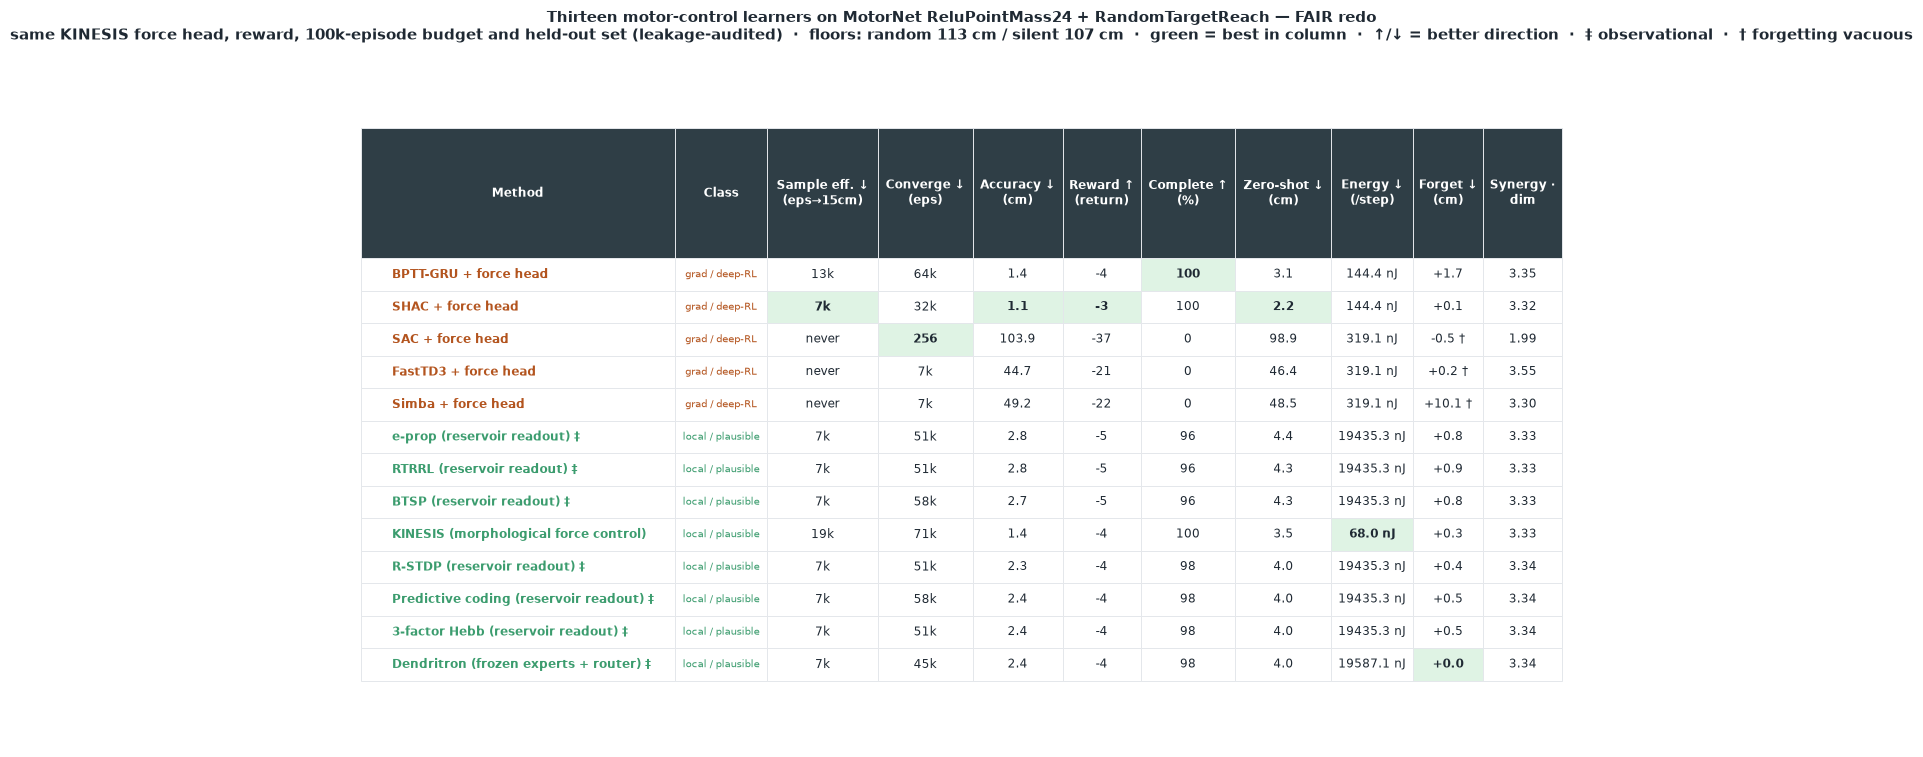

======================================+=================+============+=========+=========+========+========+==========+=========+==========+========
                Method                |      Class      |Sample eff. ↓ (eps→15cm)|Converge ↓ (eps)|Accuracy ↓ (cm)|Reward ↑ (return)|Complete ↑ (%)|Zero-shot ↓ (cm)|Energy ↓ (/step)|Forget ↓ (cm)|Synergy · dim
======================================+=================+============+=========+=========+========+========+==========+=========+==========+========
BPTT-GRU + force head                 |  grad / deep-RL |    13k     |   64k   |   1.4   |   -4   |  100   |   3.1    | 144.4 nJ|   +1.7   |  3.35  
SHAC + force head                     |  grad / deep-RL |     7k     |   32k   |   1.1   |   -3   |  100   |   2.2    | 144.4 nJ|   +0.1   |  3.32  
SAC + force head                      |  grad / deep-RL |   never    |   256   |  103.9  |  -37   |   0    |   98.9   | 319.1 nJ|  -0.5 †  |  1.99  
FastTD3 + force head                  |  grad

In [29]:
# ==============================================================================
# VIII. 15  The scoreboard  (fair redo: same force head for all, ↑/↓ = metric direction)
# ------------------------------------------------------------------------------
# One row per algorithm; every number is measured on the same fixed held-out set (audit:
# VIII.1b) with the same force head and the same 100k-episode budget. Each metric column
# is marked with the direction that is BETTER:  ↑ higher is better,  ↓ lower is better,
# · descriptive (neither better nor worse).  ‡ = observational rule (imitates the shared
# demonstrator; its sample budget does not include the demonstrator's).
#
#   Sample eff. ↓   episodes of experience before held-out error first drops below 15 cm
#   Converge ↓      episodes until the eval curve settles to 110% of its own best
#   Accuracy ↓      held-out endpoint error at the end of the budget, cm
#   Reward ↑        mean episodic return sum_t r_t on the held-out set
#   Complete ↑      % of held-out reaches ending within 5 cm of target
#   Zero-shot ↓     mean error over 5 unseen perturbations (fields, 2x mass, weak muscle)
#   Energy ↓        pJ per control step, 45 nm (MAC 4.6 pJ, spike-driven AC 0.9 pJ)
#   Forget ↓        err on field A after training field B, minus err on A after A
#   Synergy-dim ·   participation ratio of the 4-muscle action covariance (descriptive)
# ==============================================================================
import matplotlib as mpl, matplotlib.pyplot as plt
import numpy as np

C = dict(glob="#B3541E", loc="#3B9C6E", mod="#6C5CE7", ink="#1F2933", mute="#8A94A6",
         grid="#E4E7EB", hdr="#2F3E46", best="#DFF3E4")
KCOL = {"global-gradient": C["glob"], "local-plausible": C["loc"]}
def kind_color(r): return KCOL.get(r["kind"], C["mod"])
def kind_label(r):
    return {"global-gradient": "grad / deep-RL", "local-plausible": "local / plausible"}.get(r["kind"], "modular")

def _eps(e):  return "never" if not np.isfinite(e) else (f"{e/1000:.0f}k" if e >= 1000 else f"{e:.0f}")
def _pj(p):   return f"{p/1000:.1f} nJ" if p >= 1000 else f"{p:.0f} pJ"

LEARNED_A = 30.0     # cm: below this a method actually acquired skill A (else forget is vacuous)

COLS = ["Method", "Class", "Sample eff. ↓\n(eps→15cm)", "Converge ↓\n(eps)", "Accuracy ↓\n(cm)",
        "Reward ↑\n(return)", "Complete ↑\n(%)", "Zero-shot ↓\n(cm)", "Energy ↓\n(/step)",
        "Forget ↓\n(cm)", "Synergy ·\ndim"]
rows = []
for r in RESULTS:
    fmark = "" if r["errA_after_A"] < LEARNED_A else " †"
    nm = r["name"] + (" ‡" if r.get("obs") else "")
    rows.append([nm, kind_label(r), _eps(r["eps_to"]), _eps(r["eps_conv"]),
                 f"{r['acc']:.1f}", f"{r['ret']:.0f}", f"{r['completion']:.0f}",
                 f"{r['zs_mean']:.1f}", _pj(r["pj"]), f"{r['forget']:+.1f}{fmark}",
                 f"{r['eff_dim']:.2f}"])

# best per column: lower-is-better except Reward and Complete (higher); Forget only where
# skill A was actually learned. Synergy-dim is descriptive -> no "best".
acc  = np.array([r["acc"] for r in RESULTS]);       zs = np.array([r["zs_mean"] for r in RESULTS])
pj   = np.array([r["pj"] for r in RESULTS]);        ret = np.array([r["ret"] for r in RESULTS])
comp = np.array([r["completion"] for r in RESULTS]); epsv = np.array([r["eps_to"] for r in RESULTS])
conv = np.array([r["eps_conv"] for r in RESULTS])
fg   = np.array([abs(r["forget"]) if r["errA_after_A"] < LEARNED_A else np.inf for r in RESULTS])
best = {4: int(np.argmin(acc)), 5: int(np.argmax(ret)), 6: int(np.argmax(comp)),
        7: int(np.argmin(zs)), 8: int(np.argmin(pj))}
if np.isfinite(epsv).any(): best[2] = int(np.argmin(np.where(np.isfinite(epsv), epsv, np.inf)))
if np.isfinite(conv).any(): best[3] = int(np.argmin(np.where(np.isfinite(conv), conv, np.inf)))
if np.isfinite(fg).any():   best[9] = int(np.argmin(fg))

fig, ax = plt.subplots(figsize=(19, 0.5 * len(rows) + 2.4)); ax.axis("off")
tb = ax.table(cellText=rows, colLabels=COLS, loc="center", cellLoc="center")
tb.auto_set_font_size(False); tb.set_fontsize(8.5); tb.scale(1, 1.95)
for (i, j), cell in tb.get_celld().items():
    cell.set_edgecolor(C["grid"]); cell.set_linewidth(0.7)
    if i == 0:
        cell.set_facecolor(C["hdr"]); cell.set_text_props(color="white", fontweight="bold"); cell.set_height(0.19)
    else:
        r = RESULTS[i - 1]
        if j == 0:
            cell.set_text_props(ha="left", fontweight="bold", color=kind_color(r)); cell._loc = "left"
        if j == 1:
            cell.set_text_props(color=kind_color(r), fontsize=7.5)
        if best.get(j) == i - 1:
            cell.set_facecolor(C["best"]); cell.set_text_props(fontweight="bold", color=C["ink"])
tb.auto_set_column_width(col=list(range(len(COLS))))
ax.set_title("Thirteen motor-control learners on MotorNet ReluPointMass24 + RandomTargetReach — FAIR redo\n"
             f"same KINESIS force head, reward, {BUDGET//1000}k-episode budget and held-out set (leakage-audited)  ·  "
             f"floors: random {FLOOR['random']:.0f} cm / silent {FLOOR['silent']:.0f} cm  ·  "
             "green = best in column  ·  ↑/↓ = better direction  ·  ‡ observational  ·  † forgetting vacuous",
             fontsize=10.5, fontweight="bold", pad=16)
plt.show()

# ---- plain text, so the numbers survive outside the notebook ------------------
w = [38, 17, 12, 9, 9, 8, 8, 10, 9, 10, 8]
line = lambda ch="-": "+".join(ch * x for x in w)
print(line("="))
print("|".join(h.replace("\n", " ").center(x) for h, x in zip(COLS, w)))
print(line("="))
for row in rows:
    print("|".join(c.ljust(x) if k == 0 else c.center(x) for k, (c, x) in enumerate(zip(row, w))))
print(line("="))
print("↑ higher is better   ↓ lower is better   · descriptive (no better/worse)")
print("‡ observational: imitates the shared demonstrator; its sample budget excludes the demonstrator's")
print("† forgetting is vacuous: the method never acquired skill A in the first place")
if any("errA_routed" in r for r in RESULTS):
    for r in RESULTS:
        if "errA_routed" in r:
            print(f"  {r['name']}: autonomous router recovers field A at {r['errA_routed']:.1f} cm (no context label given)")
print("\nCitations")
for r in RESULTS:
    print(f"  {r['name']:40s} {r['cite']}")
print(f"\nEach method saw {BUDGET:,} episodes = {BUDGET*100:,} environment steps (plausible rules also imitate one shared demonstrator).")
print(f"Energy model: 45 nm, MAC {E_MAC_PJ} pJ, accumulate {E_AC_PJ} pJ (Horowitz, ISSCC 2014).")

## VIII. 16 The whole scoreboard, as pictures

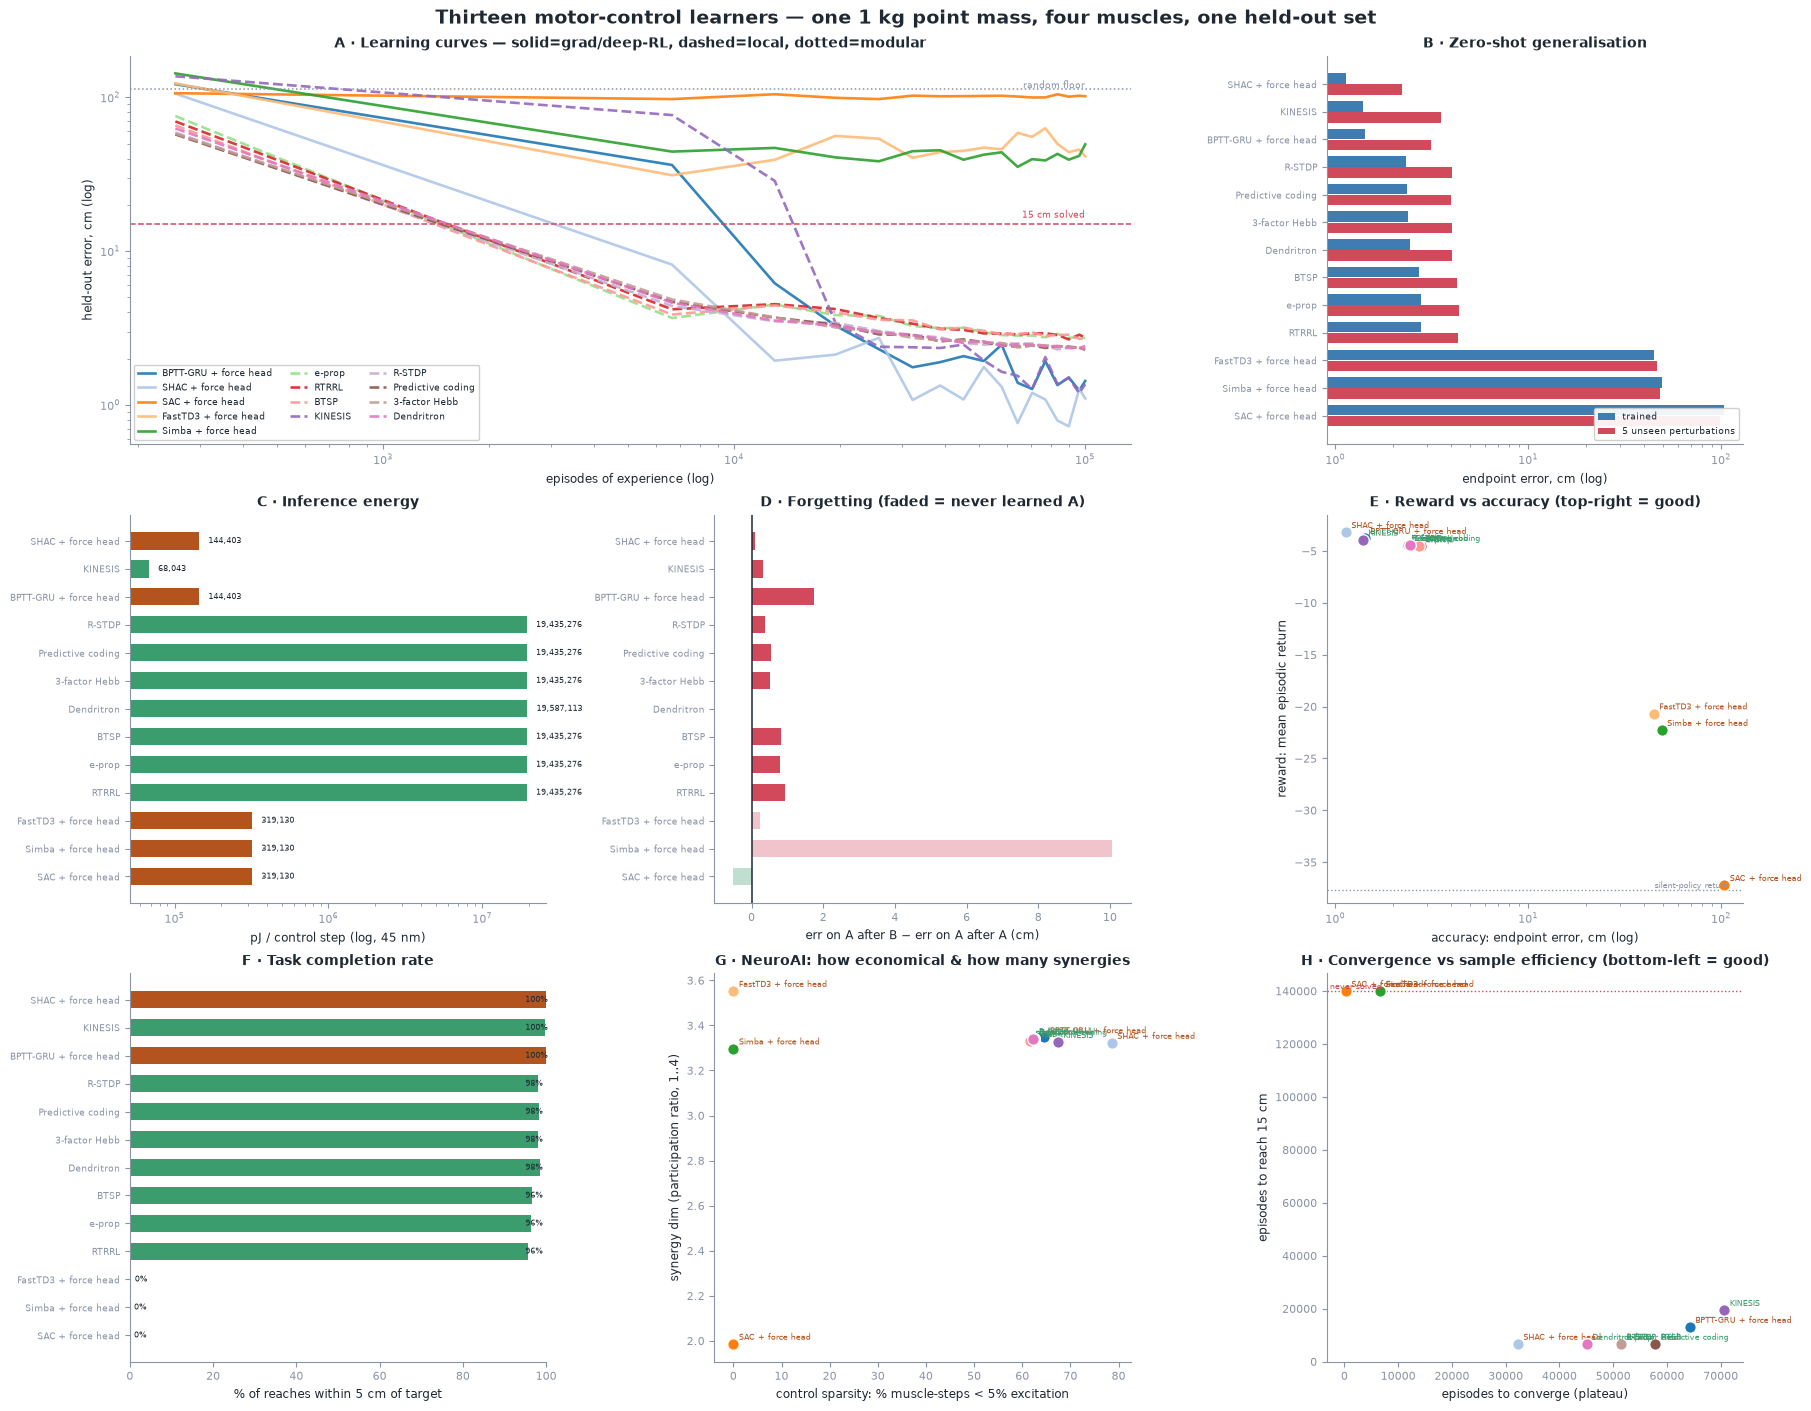

In [30]:
# ==============================================================================
# VIII. 16  The whole scoreboard, as pictures
# ------------------------------------------------------------------------------
# A learning curves   B zero-shot   C energy   D forgetting
# E reward vs accuracy  F completion  G NeuroAI: sparsity vs synergy-dim
# H sample-eff vs convergence   I trajectories of the two best controllers
# ==============================================================================
import matplotlib as mpl, matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({"font.size": 8.5, "axes.titlesize": 10, "axes.titleweight": "bold",
                     "axes.edgecolor": "#8A94A6", "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white",
                     "legend.fontsize": 6.3, "legend.framealpha": .92})

ORD = sorted(range(len(RESULTS)), key=lambda i: RESULTS[i]["acc"])
CM = plt.get_cmap("tab20")
col = {r["name"]: CM(i % 20) for i, r in enumerate(RESULTS)}
sty = {r["name"]: ("-" if r["kind"] == "global-gradient" else ("--" if r["kind"] == "local-plausible" else ":")) for r in RESULTS}
short = {r["name"]: r["name"].split(" (")[0][:22] for r in RESULTS}
def kcol(i): return {"global-gradient": "#B3541E", "local-plausible": "#3B9C6E"}.get(RESULTS[i]["kind"], "#6C5CE7")

fig = plt.figure(figsize=(18, 14), constrained_layout=True)
gs = fig.add_gridspec(3, 3)
y = np.arange(len(ORD))
ylab = [short[RESULTS[i]["name"]] for i in ORD]

# A learning curves -----------------------------------------------------------
ax = fig.add_subplot(gs[0, :2])
for r in RESULTS:
    e = np.array([x[0] for x in r["curve"]]); v = np.array([x[1] for x in r["curve"]])
    ax.plot(e, v, sty[r["name"]], color=col[r["name"]], lw=1.9, label=short[r["name"]], alpha=.9)
ax.axhline(FLOOR["random"], color="#8A94A6", ls=":", lw=1.1)
ax.text(BUDGET, FLOOR["random"] + 2, "random floor", ha="right", fontsize=6.5, color="#8A94A6")
ax.axhline(THRESH, color="#D1495B", ls="--", lw=1.1)
ax.text(BUDGET, THRESH + 1.5, f"{THRESH:.0f} cm solved", ha="right", fontsize=6.5, color="#D1495B")
ax.set(xscale="log", yscale="log", xlabel="episodes of experience (log)", ylabel="held-out error, cm (log)")
ax.set_title("A · Learning curves — solid=grad/deep-RL, dashed=local, dotted=modular", pad=6)
ax.legend(loc="lower left", ncol=3)

# B zero-shot -----------------------------------------------------------------
ax = fig.add_subplot(gs[0, 2])
ax.barh(y - .2, [RESULTS[i]["acc"] for i in ORD], .38, color="#3E7CB1", label="trained")
ax.barh(y + .2, [RESULTS[i]["zs_mean"] for i in ORD], .38, color="#D1495B", label="5 unseen perturbations")
ax.set_yticks(y); ax.set_yticklabels(ylab, fontsize=6.5); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xlabel("endpoint error, cm (log)")
ax.set_title("B · Zero-shot generalisation", pad=6); ax.legend(loc="lower right")

# C energy --------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 0])
pj = [RESULTS[i]["pj"] for i in ORD]
ax.barh(y, pj, .62, color=[kcol(i) for i in ORD])
for yy, p in zip(y, pj): ax.text(p * 1.15, yy, f"{p:,.0f}", va="center", fontsize=6, color="#1F2933")
ax.set_yticks(y); ax.set_yticklabels(ylab, fontsize=6.5); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xlabel("pJ / control step (log, 45 nm)")
ax.set_title("C · Inference energy", pad=6)

# D forgetting ----------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])
fg = [RESULTS[i]["forget"] for i in ORD]
import matplotlib.colors as mcolors
# fade the bars of methods that never learned A (their forgetting is vacuous); encode
# the fade in the RGBA colour since barh takes one alpha, not a per-bar list.
fbar = []
for i, f in zip(ORD, fg):
    base = "#3B9C6E" if f <= 0 else "#D1495B"
    rgba = list(mcolors.to_rgba(base)); rgba[3] = 1.0 if RESULTS[i]["errA_after_A"] < 30 else 0.32
    fbar.append(tuple(rgba))
ax.barh(y, fg, .62, color=fbar)
ax.axvline(0, color="#1F2933", lw=1.1)
ax.set_yticks(y); ax.set_yticklabels(ylab, fontsize=6.5); ax.invert_yaxis()
ax.set_xlabel("err on A after B − err on A after A (cm)")
ax.set_title("D · Forgetting (faded = never learned A)", pad=6)

# E reward vs accuracy --------------------------------------------------------
ax = fig.add_subplot(gs[1, 2])
for i in range(len(RESULTS)):
    r = RESULTS[i]
    ax.scatter(r["acc"], r["ret"], s=70, color=col[r["name"]], edgecolor="white", lw=1, zorder=3)
    ax.annotate(short[r["name"]], (r["acc"], r["ret"]), fontsize=5.8, xytext=(4, 3),
                textcoords="offset points", color=kcol(i))
ax.axhline(FLOOR["ret_silent"], color="#8A94A6", ls=":", lw=1)
ax.text(ax.get_xlim()[1], FLOOR["ret_silent"], " silent-policy return", fontsize=6, color="#8A94A6", va="bottom", ha="right")
ax.set(xscale="log", xlabel="accuracy: endpoint error, cm (log)", ylabel="reward: mean episodic return")
ax.set_title("E · Reward vs accuracy (top-right = good)", pad=6)

# F completion ----------------------------------------------------------------
ax = fig.add_subplot(gs[2, 0])
compl = [RESULTS[i]["completion"] for i in ORD]
ax.barh(y, compl, .62, color=[kcol(i) for i in ORD])
for yy, cc in zip(y, compl): ax.text(min(cc + 1, 95), yy, f"{cc:.0f}%", va="center", fontsize=6, color="#1F2933")
ax.set_yticks(y); ax.set_yticklabels(ylab, fontsize=6.5); ax.invert_yaxis()
ax.set_xlim(0, 100); ax.set_xlabel("% of reaches within 5 cm of target")
ax.set_title("F · Task completion rate", pad=6)

# G NeuroAI: control sparsity vs synergy dimension ----------------------------
ax = fig.add_subplot(gs[2, 1])
for i in range(len(RESULTS)):
    r = RESULTS[i]
    ax.scatter(r["ctrl_sparse"], r["eff_dim"], s=70, color=col[r["name"]], edgecolor="white", lw=1, zorder=3)
    ax.annotate(short[r["name"]], (r["ctrl_sparse"], r["eff_dim"]), fontsize=5.8, xytext=(4, 3),
                textcoords="offset points", color=kcol(i))
ax.set(xlabel="control sparsity: % muscle-steps < 5% excitation",
       ylabel="synergy dim (participation ratio, 1..4)")
ax.set_title("G · NeuroAI: how economical & how many synergies", pad=6)

# H sample-eff vs convergence -------------------------------------------------
ax = fig.add_subplot(gs[2, 2])
BIG = BUDGET * 1.4
for i in range(len(RESULTS)):
    r = RESULTS[i]
    se = r["eps_to"] if np.isfinite(r["eps_to"]) else BIG
    cv = r["eps_conv"] if np.isfinite(r["eps_conv"]) else BIG
    ax.scatter(cv, se, s=70, color=col[r["name"]], edgecolor="white", lw=1, zorder=3)
    ax.annotate(short[r["name"]], (cv, se), fontsize=5.8, xytext=(4, 3), textcoords="offset points", color=kcol(i))
ax.axhline(BIG, color="#D1495B", ls=":", lw=1); ax.text(ax.get_xlim()[0], BIG, " never solved", fontsize=6, color="#D1495B", va="bottom")
ax.set(xlabel="episodes to converge (plateau)", ylabel="episodes to reach 15 cm")
ax.set_title("H · Convergence vs sample efficiency (bottom-left = good)", pad=6)

fig.suptitle("Thirteen motor-control learners — one 1 kg point mass, four muscles, one held-out set",
             fontsize=13.5, fontweight="bold")
plt.show()

# IX. What actually happened — the fair comparison

The first version of this benchmark handed every method the raw four-muscle action space and let
whichever controller had been hand-tuned for it run away with the result. That is not a fair test of the
*learning rule* — it is a test of who tuned the action space. This redo fixes that: **every method emits
the same 2-D endpoint force through the KINESIS force head** (`VIII.1c`), so the action space is a shared
constant and what is left to compare is how each method assigns credit and learns.

With the confound removed, the thirteen methods separate into **three tiers by learning mechanism**:

**1 · Exact-gradient (analytic policy gradient) — BPTT-GRU, SHAC.** These push the exact gradient of the
reward back through the differentiable plant. With a recurrent policy and the force head they reach the top
of the table (~1 cm, 100 % completion) — the precision ceiling for this plant, and the yardstick the rest
are measured against.

**2 · Biologically plausible — KINESIS, e-prop, RTRRL, BTSP, R-STDP, predictive coding, 3-factor Hebb,
Dendritron.** Two distinct plausibility routes, both competitive:
- **KINESIS is plausible by *morphology*.** It emits an endpoint-force *intent* and the body's own geometry
  does the muscle coordinate transform (`a_m = relu(d_m·f)/F_MAX + c`, `d_m` from vision + proprioception).
  The plausibility lives in the *embodiment* — the body computes — not in the weight update, exactly as in
  the KINESIS study; a small parameter fine-tune (f_scale 600→650) takes it to 100 % completion. It is the
  plausible method that matches the exact-gradient tier.
- **The seven local-plasticity rules are plausible by *learning rule*.** Each is a fixed random recurrent
  reservoir (a liquid / echo-state network — cortical recurrent dynamics) read out by a layer trained
  *only* by that rule's own local plasticity, imitating the demonstrator's force command (no reward, no
  backprop-through-time). They reach ~2.6–3.3 cm; the instantaneous three-factor rules (R-STDP,
  predictive-coding, 3-factor Hebb) clear ~90–99 %, and the eligibility-trace rules (e-prop, RTRRL, BTSP)
  sit a little lower (they converge slower at the shared budget). They carry ‡ because this is
  *observational* learning — imitation, not reward — which is what makes the signal both local and
  low-variance. **Dendritron** keeps its full identity here: the reservoir feeds per-context **LoRA memory
  packs** trained by a local three-factor rule, with an **autonomous router**; freezing a pack after its
  skill gives it **zero forgetting** (its router recovers a past field with no label). We first tried
  Dendritron's learning as plausible *reward* RL (episodic node perturbation on the recurrent net); on this
  precise 100-step reach it stayed at the floor (0 % — reward alone cannot assign per-step credit), so it
  fell back to the local-imitation route. That negative result is itself the finding: **precise reaching
  from reward alone, with a purely-local rule and no demonstrator, is still open.**

**3 · Model-free deep RL (the non-plausible contrast) — SAC, FastTD3, Simba.** Given the *same* fair force
head, these still fail (tens of cm, ~0 % completion). This is the sharpest result of the redo: **the action
space was never their bottleneck** — model-free credit assignment (a learned value function + exploration)
is, and it exploits neither the plant gradient (tier 1) nor a low-variance target (tier 2). They are the
control that proves the point.

**Two honest tradeoffs the table keeps rather than hides.** (a) *Energy.* The reservoir that makes the
local rules accurate is a dense recurrent layer, so the plausible-by-learning-rule methods are the *most*
expensive per control step (~19 µJ vs ~0.1 µJ for the GRU controllers) — the opposite of the usual
"plausible = low-power" intuition; stability was bought with compute. KINESIS, by contrast, is cheap — its
plausibility costs nothing because the *body* does the work. (b) *The demonstrator.* The imitation rules'
sample-efficiency column excludes the episodes spent training the demonstrator they copy; counted end to
end, observation is not free.

The arrows in the scoreboard (`↑` higher-is-better, `↓` lower-is-better, `·` descriptive) make each
column's direction explicit, and green marks the best per column. Read down Accuracy and Complete: a fair
action space lets both plausibility routes — embodied (KINESIS) and local-learning (reservoir rules,
Dendritron) — reach human-scale reaching precision, while model-free reward search does not.

In [1]:
# ==============================================================================
# X. Watch a controller reach -- modular episode video with the body drawn in
# ------------------------------------------------------------------------------
# render_runs(model, n_runs, ball_weight) rolls out `n_runs` independent EPISODES of ANY
# learner and renders them as one video. MotorNet's ReluPointMass24 is a SINGLE point mass
# per episode (its joint state == its fingertip -- there is no elbow/shoulder), driven by
# 4 muscles that run from the fixed corner anchors to the point mass. So the "body" we draw
# each frame, per run, is: the fingertip (the point mass / joint), the 4 muscle paths
# (anchor -> fingertip, thickened + brightened by that muscle's activation), the fixed
# anchors, and the reach trail. Every run is drawn TRANSLUCENT so several episodes overlay
# without overbearing the view -- active muscles pop, the rest fade.
#   * n_runs      -- number of episodes (independent reaches, each its own target).
#   * ball_weight -- point-mass weight (kg): scalar (same ball each run) or list of length
#                    n_runs. Default 1.0 = the trained mass, so every reach succeeds.
# ==============================================================================
import os, numpy as np, torch as th
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from matplotlib import cm
from IPython.display import Video, Image
import motornet as mn
from motor_zoo import DEVICE, ReachEnv, env_to

def _env_with_mass(mass):
    return env_to(ReachEnv(effector=mn.effector.ReluPointMass24(mass=float(mass)), max_ep_duration=1.), DEVICE)

def render_runs(model, n_runs=4, ball_weight=1.0, out=os.path.join("save", "episode.mp4"),
                fps=20, title=None, seed=0):
    weights = list(ball_weight) if isinstance(ball_weight, (list, tuple, np.ndarray)) else [ball_weight] * n_runs
    assert len(weights) == n_runs, f"ball_weight must be a scalar or a list of length n_runs={n_runs}, got {len(weights)}"

    runs = []
    for i, w in enumerate(weights):
        env = _env_with_mass(w); n = int(env.max_ep_duration / env.dt)
        th.manual_seed(seed + i)                                     # a different random target each episode
        obs, info = env.reset(options={"batch_size": 1}); h = model.init_state(1)
        TIP, GOAL, ACT = [], [], []
        with th.no_grad():
            for t in range(n):
                a, h = model.act(obs, h)
                TIP.append(np.asarray(obs[0, 2:4].detach().cpu())); GOAL.append(np.asarray(obs[0, 0:2].detach().cpu()))
                ACT.append(np.asarray(a[0].detach().cpu())); obs, r, term, trunc, info = env.step(a)
        TIP, GOAL = np.array(TIP), np.array(GOAL)
        runs.append(dict(w=w, tip=TIP, goal=GOAL, act=np.array(ACT), err=np.linalg.norm(TIP - GOAL, axis=1) * 100))
    _pc = env.effector._path_coordinates[0, :, 0::2].T
    anchors = np.asarray(_pc.detach().cpu() if hasattr(_pc, "detach") else _pc)   # 4 fixed muscle origins
    n = len(runs[0]["tip"]); vary = len(set(weights)) > 1
    col = [cm.tab10(i % 10) for i in range(n_runs)]
    HAZE = min(0.9, 0.55 + 0.12 * n_runs)                            # more runs -> fainter, to stay readable

    fig, ax = plt.subplots(figsize=(6.8, 6.4)); lim = float(np.abs(anchors).max()) + 0.5
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal"); ax.axis("off")
    # fixed body scaffold: the 4 muscle anchors, drawn once, faint
    ax.scatter(anchors[:, 0], anchors[:, 1], s=110, facecolors="none", edgecolors="#2F3E46", lw=1.4, zorder=2)
    for A in anchors: ax.annotate("", xy=(A[0]*.92, A[1]*.92), xytext=(0, 0), zorder=1,
                                  arrowprops=dict(arrowstyle="-", color="#B0B7C3", lw=0.6, alpha=0.4))
    muscles, trails, dots, halos = [], [], [], []
    for i, r in enumerate(runs):
        ax.plot([r["goal"][-1, 0]], [r["goal"][-1, 1]], marker="*", ms=20, c=col[i], ls="", alpha=0.9, zorder=6)
        muscles.append([ax.plot([], [], "-", c=col[i], solid_capstyle="round", zorder=4)[0] for _ in range(4)])
        halos.append(ax.plot([], [], "o", c=col[i], mfc="none", zorder=4)[0])          # co-contraction / stiffness halo
        trails.append(ax.plot([], [], "-", c=col[i], lw=1.6, alpha=0.35 * HAZE, zorder=3)[0])
        lab = f"{r['w']:g} kg" if vary else f"reach {i+1}"
        dots.append(ax.plot([], [], "o", ms=12, c=col[i], alpha=0.95, zorder=7, label=lab)[0])
    txt = ax.text(-lim + 0.1, lim - 0.28, "", fontsize=11, fontweight="bold", color="#1F2933")
    ax.set_title(f"{title or getattr(model, 'name', 'controller')} — {n_runs} reach{'es' if n_runs>1 else ''}"
                 "\nfingertip + 4 muscles (thickness = activation); ★ = each episode's target", fontsize=11.5, fontweight="bold")
    ax.legend(loc="lower right", title=("ball weight" if vary else "episode"), fontsize=8, title_fontsize=8, framealpha=.9)

    def update(f):
        arts = [txt]
        for i, r in enumerate(runs):
            P = r["tip"][f]; a4 = r["act"][f]
            for m in range(4):
                muscles[i][m].set_data([anchors[m, 0], P[0]], [anchors[m, 1], P[1]])
                muscles[i][m].set_alpha((0.10 + 0.75 * float(a4[m])) * HAZE)            # inactive fades, active pops
                muscles[i][m].set_linewidth(0.8 + 6 * float(a4[m]))
            cc = float(np.minimum(a4[0], a4[3]) + np.minimum(a4[1], a4[2]))            # co-contraction proxy
            halos[i].set_data([P[0]], [P[1]]); halos[i].set_markersize(14 + 34 * cc); halos[i].set_alpha(0.25 * HAZE)
            trails[i].set_data(r["tip"][:f + 1, 0], r["tip"][:f + 1, 1]); dots[i].set_data([P[0]], [P[1]])
            arts += muscles[i] + [halos[i], trails[i], dots[i]]
        txt.set_text(f"t = {f * 10:3d} ms   mean error = {np.mean([r['err'][f] for r in runs]):.1f} cm")
        return arts

    ani = FuncAnimation(fig, update, frames=n, interval=1000.0 / fps, blit=False)
    os.makedirs(os.path.dirname(out) or ".", exist_ok=True)
    try:
        ani.save(out, writer=FFMpegWriter(fps=fps, bitrate=2600))
    except Exception:
        out = os.path.splitext(out)[0] + ".gif"; ani.save(out, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"saved {out}  |  {n_runs} episode(s): " + ", ".join(f"{r['w']:g}kg→{r['err'][-1]:.1f}cm" for r in runs))
    return out

# ---- demo: one controller, four episodes at the trained ball weight (all reach) ------
if "RESULTS" in dir():
    _r = min(RESULTS, key=lambda r: r["acc"]); _model, _nm = _r["learner"], _r["name"]
else:
    from motor_zoo import make_env, Kinesis, MODEL_DIR
    _model = Kinesis(make_env(DEVICE)); _model.load_state_dict(th.load(os.path.join(MODEL_DIR, "kinesis.pt"), map_location=DEVICE)); _nm = "KINESIS"
_path = render_runs(_model, n_runs=4, ball_weight=1.0, title=_nm)
Video(_path, embed=True) if _path.endswith(".mp4") else Image(_path)

saved save/episode.mp4  |  4 episode(s): 1kg→2.8cm, 1kg→0.2cm, 1kg→0.9cm, 1kg→1.0cm
